In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import tensorflow as tf
from sklearn.preprocessing import StandardScaler

In [19]:
# Load by file name
R2502_2503 = pd.read_pickle("R2502_2503.pkl")
R2503_2502 = pd.read_pickle("R2503_2502.pkl")
R2503_2504 = pd.read_pickle("R2503_2504.pkl")
R2504_2503 = pd.read_pickle("R2504_2503.pkl")
R2502_2504 = pd.read_pickle("R2502_2504.pkl")
R2504_2502 = pd.read_pickle("R2504_2502.pkl")

F2504 = pd.read_pickle("2504.pkl")

In [20]:
from pathlib import Path

# 1) Does a directory exist?
base = Path("/home/seismic/AxialFetch/MJ03F-B")
print(base, "→", base.exists(), "(dir)" if base.is_dir() else "(not a dir)")

# 2) Does one specific file exist?
f = base / "MJ03F-B2022DIFF-PRESS-15min.txt"
print(f, "→", f.exists())

# 3) Quick sweep over a pattern
for p in base.glob("MJ03F-B*DIFF-PRESS-15min.txt"):
    print("found:", p.name)

/home/seismic/AxialFetch/MJ03F-B → True (dir)
/home/seismic/AxialFetch/MJ03F-B/MJ03F-B2022DIFF-PRESS-15min.txt → True
found: MJ03F-B2023DIFF-PRESS-15min.txt
found: MJ03F-B2022DIFF-PRESS-15min.txt
found: MJ03F-B2021DIFF-PRESS-15min.txt
found: MJ03F-B2020DIFF-PRESS-15min.txt
found: MJ03F-B2019DIFF-PRESS-15min.txt
found: MJ03F-B2018DIFF-PRESS-15min.txt
found: MJ03F-B2017DIFF-PRESS-15min.txt
found: MJ03F-B2024DIFF-PRESS-15min.txt


Rows in df_pressure: 994


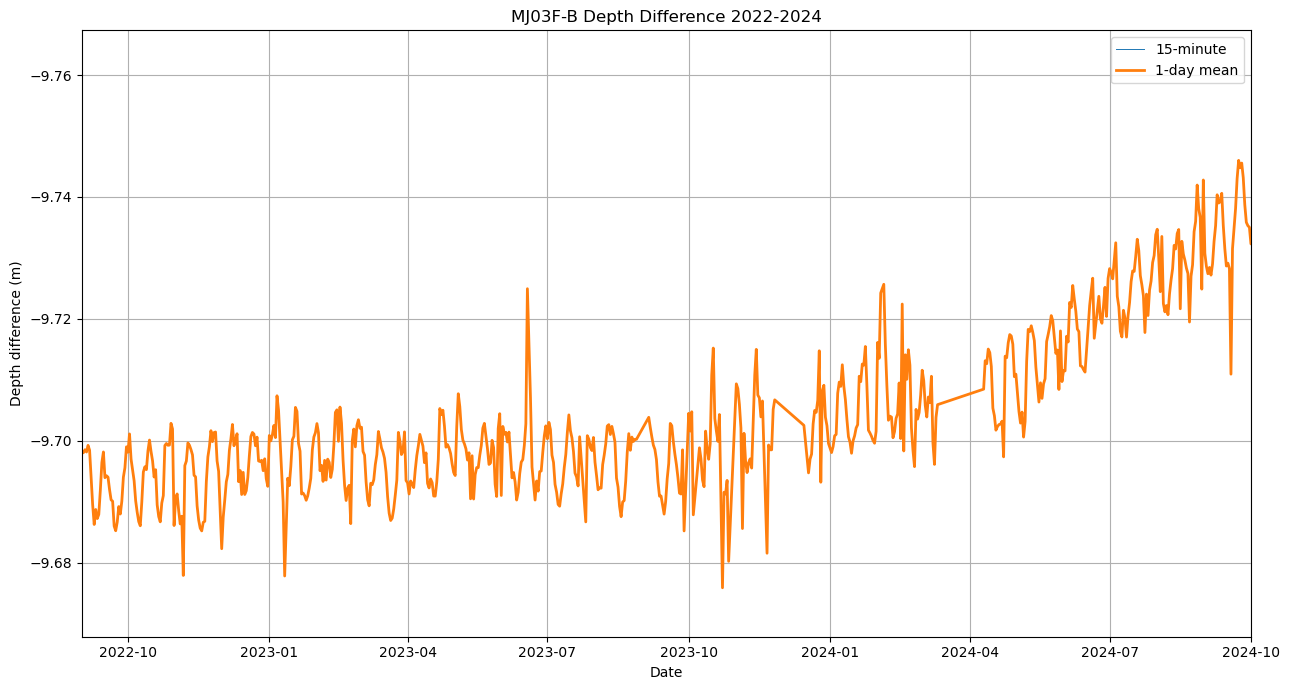

In [21]:
# MJ03F-B depth / pressure processing
# ----------------------------------
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

base_path = Path("/home/seismic/AxialFetch/MJ03F-B")
years     = range(2022, 2025)      # 2022-2024
factor    = 0.67                   # pressure-to-depth conversion

def load_series(years, suffix):
    """Read MJ03F-B DIFF-PRESS files (comma OR whitespace delimited)."""
    frames = []

    for yr in years:
        f = base_path / f"MJ03F-B{yr}DIFF-PRESS-{suffix}.txt"
        if not f.exists():
            continue

        # ---- peek at first line to decide the delimiter -----------------
        with open(f, "r") as fh:
            first_line = fh.readline()

        comma = "," in first_line
        read_opts = dict(
            comment="#",
            engine="python",          # tolerant, handles weird rows
            on_bad_lines="skip"       # silently drop malformed lines
        )

        if comma:
            df = pd.read_csv(f, **read_opts)
            # pick the known columns
            date_col      = df.columns[0]                       # e.g. 'date_1day'
            pressure_col  = (
                "pressure_diff_mean"
                if "pressure_diff_mean" in df.columns
                else df.columns[-1]                             # last numeric col
            )
            df = df[[date_col, pressure_col]]
            df.columns = ["time", "pressure_diff"]
        else:
            # whitespace version: two numeric cols after the date
            df = pd.read_csv(
                f,
                delim_whitespace=True,
                header=None,
                names=["time", "pressure_diff"],
                **read_opts,
            )

        # ---- type conversions & cleanup -------------------------------
        df["time"] = pd.to_datetime(df["time"], format="%Y/%m/%d",
                                    errors="coerce", utc=True)
        df["pressure_diff"] = pd.to_numeric(df["pressure_diff"],
                                            errors="coerce")
        df.dropna(subset=["time", "pressure_diff"], inplace=True)
        frames.append(df)

    if not frames:
        raise FileNotFoundError(f"No DIFF-PRESS-{suffix} data found.")
    return pd.concat(frames, ignore_index=True).sort_values("time")

# ----------------------------------------------------------------------
df_15min = load_series(years, "15min")
df_1day  = load_series(years, "1daymeans")

df_15min["depth_m"] = df_15min["pressure_diff"] * factor
df_1day ["depth_m"] = df_1day ["pressure_diff"] * factor

# minimalist (time, pressure) DF
df_pressure = df_1day[["time", "pressure_diff"]]

print("Rows in df_pressure:", len(df_pressure))   # sanity check

# ----------------------------------------------------------------------
# quick plot
plt.figure(figsize=(13, 7))
plt.plot(df_15min["time"], df_15min["depth_m"],
         label="15-minute", linewidth=0.7)
plt.plot(df_1day["time"],  df_1day["depth_m"],
         label="1-day mean", linewidth=2)
plt.gca().invert_yaxis()
plt.xlabel("Date")
plt.ylabel("Depth difference (m)")
plt.title("MJ03F-B Depth Difference 2022-2024")
plt.xlim(pd.Timestamp(2022, 9, 1, tz="UTC"),
         pd.Timestamp(2024, 10, 1, tz="UTC"))
#plt.ylim(-14.55, -14.45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

del df_1day

Rows in df_pressure: 994


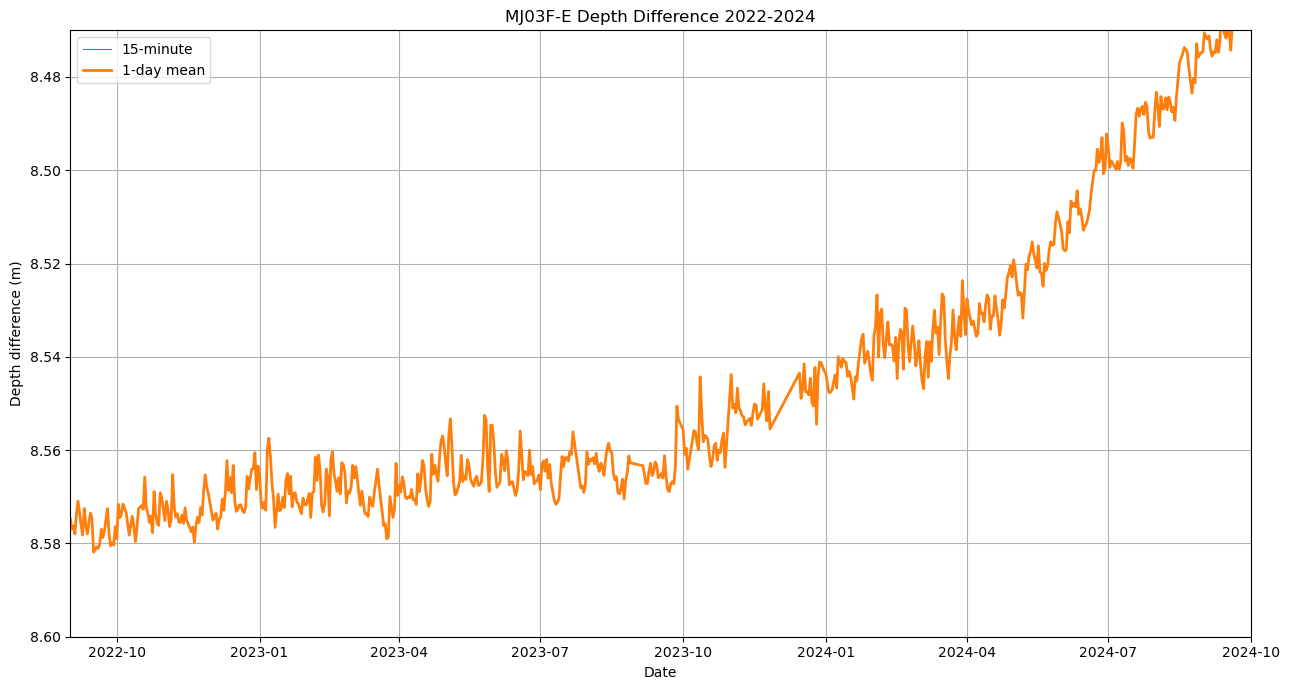

In [22]:
# MJ03F-B depth / pressure processing
# ----------------------------------
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

base_path = Path("/home/seismic/AxialFetch/MJ03F-E")
years     = range(2022, 2025)      # 2022-2024
factor    = 0.67                   # pressure-to-depth conversion

def load_series(years, suffix):
    """Read MJ03F-E DIFF-PRESS files (comma OR whitespace delimited)."""
    frames = []

    for yr in years:
        f = base_path / f"MJ03F-E{yr}DIFF-PRESS-{suffix}.txt"
        if not f.exists():
            continue

        # ---- peek at first line to decide the delimiter -----------------
        with open(f, "r") as fh:
            first_line = fh.readline()

        comma = "," in first_line
        read_opts = dict(
            comment="#",
            engine="python",          # tolerant, handles weird rows
            on_bad_lines="skip"       # silently drop malformed lines
        )

        if comma:
            df = pd.read_csv(f, **read_opts)
            # pick the known columns
            date_col      = df.columns[0]                       # e.g. 'date_1day'
            pressure_col  = (
                "pressure_diff_mean"
                if "pressure_diff_mean" in df.columns
                else df.columns[-1]                             # last numeric col
            )
            df = df[[date_col, pressure_col]]
            df.columns = ["time", "pressure_diff"]
        else:
            # whitespace version: two numeric cols after the date
            df = pd.read_csv(
                f,
                delim_whitespace=True,
                header=None,
                names=["time", "pressure_diff"],
                **read_opts,
            )

        # ---- type conversions & cleanup -------------------------------
        df["time"] = pd.to_datetime(df["time"], format="%Y/%m/%d",
                                    errors="coerce", utc=True)
        df["pressure_diff"] = pd.to_numeric(df["pressure_diff"],
                                            errors="coerce")
        df.dropna(subset=["time", "pressure_diff"], inplace=True)
        frames.append(df)

    if not frames:
        raise FileNotFoundError(f"No DIFF-PRESS-{suffix} data found.")
    return pd.concat(frames, ignore_index=True).sort_values("time")

# ----------------------------------------------------------------------
df_15min = load_series(years, "15min")
df_1day  = load_series(years, "1daymeans")

df_15min["depth_m"] = df_15min["pressure_diff"] * factor
df_1day ["depth_m"] = df_1day ["pressure_diff"] * factor

# minimalist (time, pressure) DF
df_pressure1 = df_1day[["time", "pressure_diff"]]

print("Rows in df_pressure:", len(df_pressure))   # sanity check

# ----------------------------------------------------------------------
# quick plot
plt.figure(figsize=(13, 7))
plt.plot(df_15min["time"], df_15min["depth_m"],
         label="15-minute", linewidth=0.7)
plt.plot(df_1day["time"],  df_1day["depth_m"],
         label="1-day mean", linewidth=2)
plt.gca().invert_yaxis()
plt.xlabel("Date")
plt.ylabel("Depth difference (m)")
plt.title("MJ03F-E Depth Difference 2022-2024")
plt.xlim(pd.Timestamp(2022, 9, 1, tz="UTC"),
         pd.Timestamp(2024, 10, 1, tz="UTC"))
plt.ylim(8.6, 8.47)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [23]:
import pandas as pd

# ------------------------------------------------------------------
# 1) helper → convert any table to a clean UTC-indexed Series
# ------------------------------------------------------------------
def to_series(df, time_col, value_col, fmt=None):
    s = (
        df[[time_col, value_col]]
        .assign(**{time_col: lambda d: pd.to_datetime(
            d[time_col], format=fmt, utc=True)})
        .set_index(time_col)[value_col]
        .astype(float)
        .sort_index()
        .loc[lambda x: ~x.index.duplicated(keep="first")]
    )
    return s

# ------------------------------------------------------------------
# 2) build the master grid from R2503_2504  (distance d1)
# ------------------------------------------------------------------
d1 = to_series(R2503_2502, "Record Time", "Moving Average")

df_var = d1.to_frame("d1")   # index = time, one column so far

# ------------------------------------------------------------------
# 3) prepare the other source series
# ------------------------------------------------------------------
# pressure difference p1 (comes from df_pressure)
p1 = (
    df_pressure.assign(time=pd.to_datetime(df_pressure["time"], utc=True))
               .set_index("time")["pressure_diff"]
               .astype(float)
               .sort_index()
               .loc[lambda x: ~x.index.duplicated(keep="first")]
)

p2 = (
    df_pressure1.assign(time=pd.to_datetime(df_pressure1["time"], utc=True))
               .set_index("time")["pressure_diff"]
               .astype(float)
               .sort_index()
               .loc[lambda x: ~x.index.duplicated(keep="first")]
)

# distance opposite direction d2
d2 = to_series(R2502_2503, "Record Time", "Moving Average")
d3 = to_series(R2502_2504, "Record Time", "Moving Average")
d4 = to_series(R2504_2502, "Record Time", "Moving Average")
d5 = to_series(R2503_2504, "Record Time", "Moving Average")
d6 = to_series(R2504_2503, "Record Time", "Moving Average")

# corrected pressure p2
p3 = to_series(F2504, "DateTime", "Corrected Pressure (kPa)")

In [24]:
# ------------------------------------------------------------------
# 4) interpolate everything onto the master grid
# ------------------------------------------------------------------
def onto_master(source, master_index):
    union = source.reindex(master_index.union(source.index))
    filled = union.interpolate("time")
    return filled.reindex(master_index)

df_var["p1"] = onto_master(p1, df_var.index)
df_var["d2"] = onto_master(d2, df_var.index)
df_var["p2"] = onto_master(p2, df_var.index)
df_var["p3"] = onto_master(p3, df_var.index)
df_var["d3"] = onto_master(d3, df_var.index)
df_var["d4"] = onto_master(d4, df_var.index)
df_var["d5"] = onto_master(d5, df_var.index)
df_var["d6"] = onto_master(d6, df_var.index)

# optional order
df_var = df_var[["p1", "p2", "p3", "d1", "d2", "d3", "d4", "d5", "d6"]]

# reset index so 'time' is a normal column
df_var = df_var.reset_index().rename(columns={"index": "time"})


In [35]:
# =============================================================================
# HYBRID: LINEAR + GRADIENT BOOSTING ON RESIDUALS  (with visualization)
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, pathlib

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# -----------------------------------------------------------------------------
# 0)  LOAD & CLEAN RAW DATA  (df_var in memory)
# -----------------------------------------------------------------------------
df = pd.DataFrame({
    'time':        df_var['Record Time'].values,
    'p1':          df_var['p1'].values,
    'p2':          df_var['p2'].values,
    'p3':          df_var['p3'].values,
    'r_WE':        df_var['d1'].values,
    'r_EW':        df_var['d2'].values,
    'r_WC':        df_var['d3'].values,
    'r_CW':        df_var['d4'].values,
    'r_CE':        df_var['d5'].values,
    'r_EC':        df_var['d6'].values,
})

# drop any rows with NaNs
X_base = ['p1','p2','p3']
Y_cols = ['r_WE','r_EW','r_WC','r_CW','r_CE','r_EC']
df = df.dropna(subset=X_base + Y_cols).reset_index(drop=True)

# engineer time and seasonal features
t0 = df['time'].min()
df['t_days'] = (df['time'] - t0).dt.total_seconds() / 86400.0
ω = 2*np.pi / 365.25
df['sin1'] = np.sin(ω * df['t_days'])
df['cos1'] = np.cos(ω * df['t_days'])

# assemble feature matrix
X = df[['p1','p2','p3','sin1','cos1','t_days']].values
Y = df[Y_cols].values

# chronological train/val split
split = int(0.8*len(df))
X_train, X_val = X[:split], X[split:]
Y_train, Y_val = Y[:split], Y[split:]
t_val = df['time'].values[split:]

# -----------------------------------------------------------------------------
# 1)  FIT LINEAR BASELINE
# -----------------------------------------------------------------------------
lin = LinearRegression().fit(X_train, Y_train)
Y_lin_val = lin.predict(X_val)

# compute residuals on train
Y_lin_train = lin.predict(X_train)
R_train = Y_train - Y_lin_train
R_val   = Y_val   - Y_lin_val

# -----------------------------------------------------------------------------
# 2)  MODEL RESIDUALS WITH GRADIENT BOOSTING
# -----------------------------------------------------------------------------
gb = MultiOutputRegressor(HistGradientBoostingRegressor(
        loss='squared_error', max_depth=3,
        learning_rate=0.05, l2_regularization=1.0))
gb.fit(X_train, R_train)
R_pred_val = gb.predict(X_val)

# hybrid prediction = linear + residual
Y_hyb_val = Y_lin_val + R_pred_val





Validation results (Linear vs Hybrid):


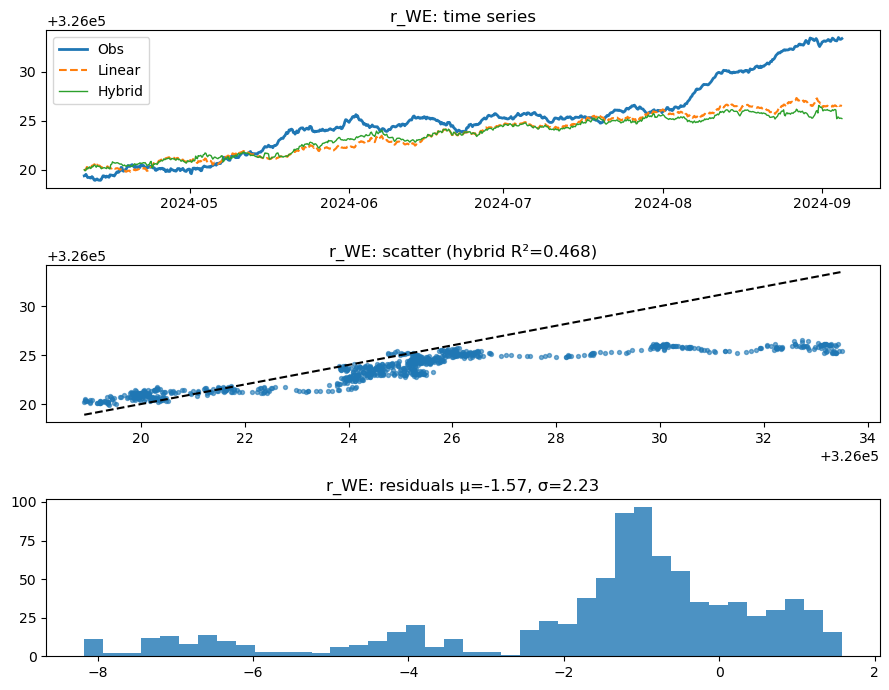

r_WE:  Linear R²= 0.563,  Hybrid R²= 0.468


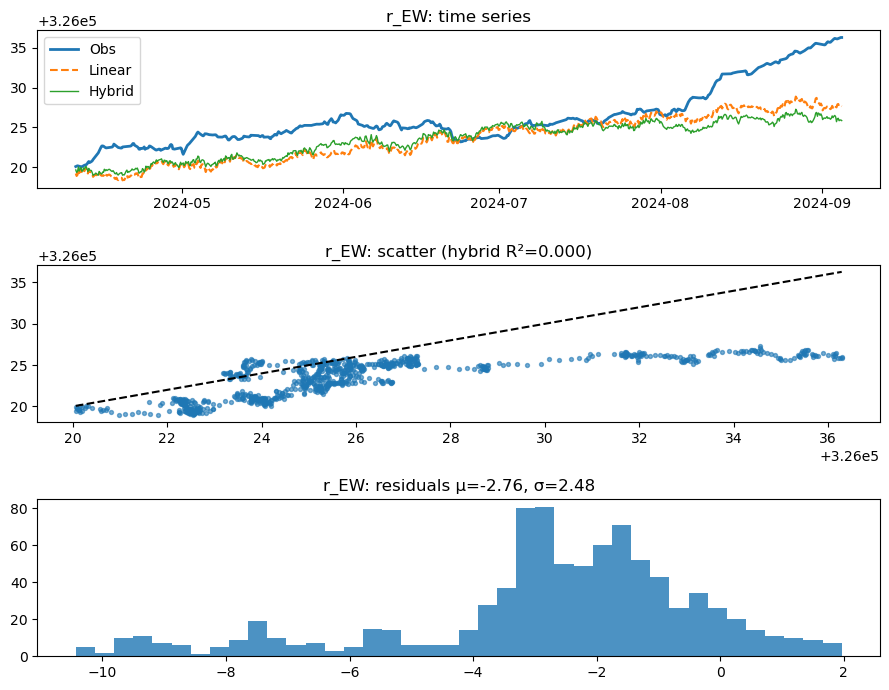

r_EW:  Linear R²= 0.158,  Hybrid R²= 0.000


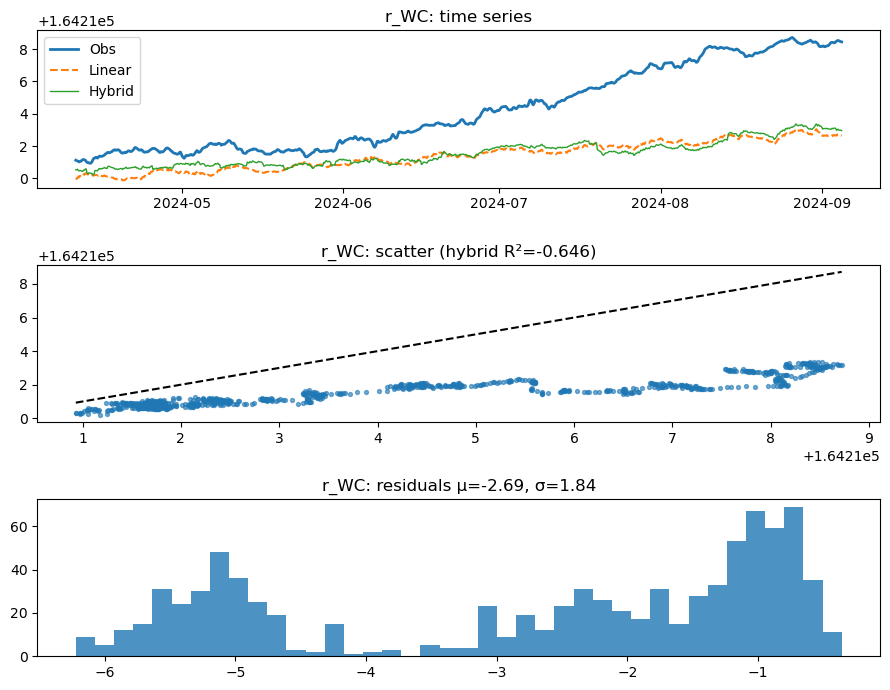

r_WC:  Linear R²=-0.709,  Hybrid R²=-0.646


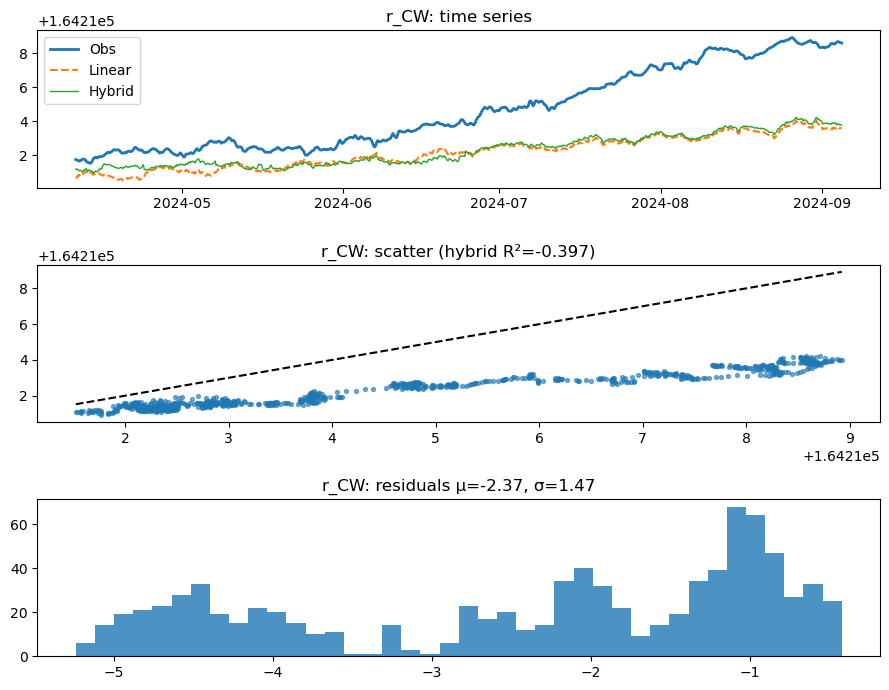

r_CW:  Linear R²=-0.510,  Hybrid R²=-0.397


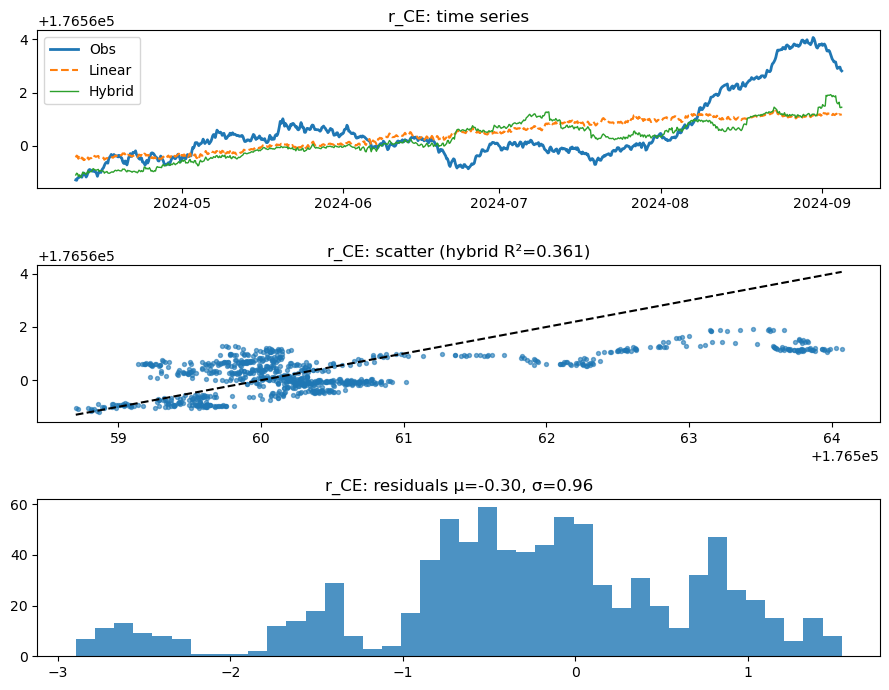

r_CE:  Linear R²= 0.321,  Hybrid R²= 0.361


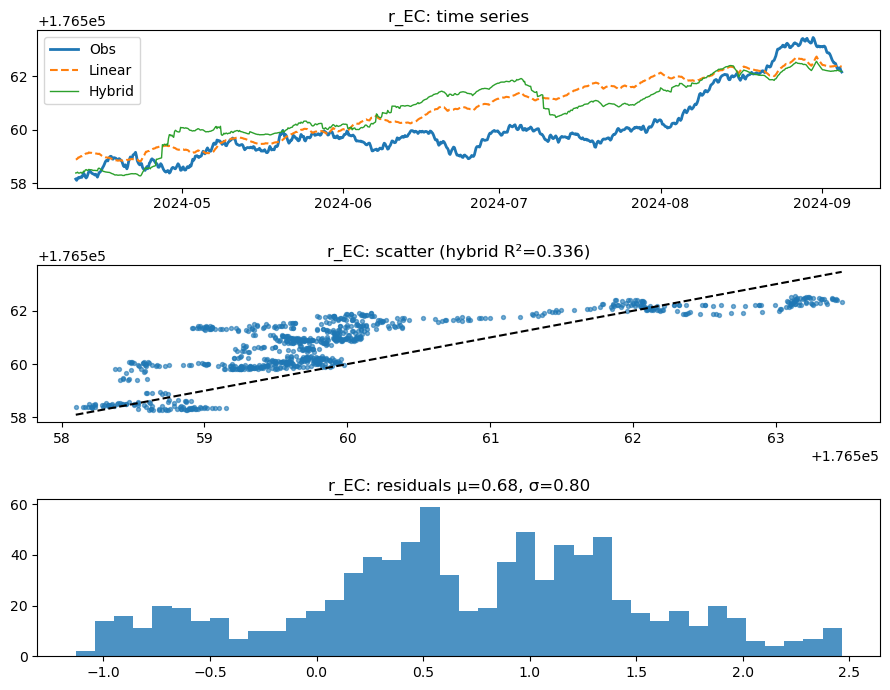

r_EC:  Linear R²= 0.374,  Hybrid R²= 0.336


In [36]:
# -----------------------------------------------------------------------------
# 3)  EVALUATE & VISUALIZE
# -----------------------------------------------------------------------------
def plot_baseline(i, name):
    fig, ax = plt.subplots(3,1,figsize=(9,7), tight_layout=True)
    # time-series
    ax[0].plot(t_val, Y_val[:,i],   label='Obs', lw=2)
    ax[0].plot(t_val, Y_lin_val[:,i],label='Linear', ls='--')
    ax[0].plot(t_val, Y_hyb_val[:,i],label='Hybrid', lw=1)
    ax[0].set_title(f"{name}: time series")
    ax[0].legend()
    # scatter
    r2 = r2_score(Y_val[:,i], Y_hyb_val[:,i])
    mn,mx = Y_val[:,i].min(), Y_val[:,i].max()
    ax[1].scatter(Y_val[:,i], Y_hyb_val[:,i], s=8, alpha=0.6)
    ax[1].plot([mn,mx],[mn,mx],'k--')
    ax[1].set_title(f"{name}: scatter (hybrid R²={r2:.3f})")
    # residual hist
    resid = Y_hyb_val[:,i]-Y_val[:,i]
    ax[2].hist(resid, bins=40, alpha=0.8)
    ax[2].set_title(f"{name}: residuals μ={resid.mean():.2f}, σ={resid.std():.2f}")
    plt.show()
    print(f"{name:>4}:  Linear R²={r2_score(Y_val[:,i],Y_lin_val[:,i]):6.3f},  Hybrid R²={r2:6.3f}")

print("\nValidation results (Linear vs Hybrid):")
for i,name in enumerate(Y_cols):
    plot_baseline(i, name)


In [42]:
# =============================================================================
# HYBRID TREND+SEASON+MLP(residual) SCRIPT  — corrected merge of residuals
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, pathlib

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.neural_network import MLPRegressor

from statsmodels.tsa.seasonal import STL

# -----------------------------------------------------------------------------
# 0) LOAD & CLEAN
# -----------------------------------------------------------------------------
df = pd.DataFrame({
    'time': df_var['Record Time'].values,
    'p1':   df_var['p1'].values,
    'p2':   df_var['p2'].values,
    'p3':   df_var['p3'].values,
    'r_WE': df_var['d1'].values,
    'r_EW': df_var['d2'].values,
    'r_WC': df_var['d3'].values,
    'r_CW': df_var['d4'].values,
    'r_CE': df_var['d5'].values,
    'r_EC': df_var['d6'].values,
})
cols = ['p1','p2','p3','r_WE','r_EW','r_WC','r_CW','r_CE','r_EC']
df = df.dropna(subset=cols).reset_index(drop=True)

# linear time feature
t0 = df['time'].min()
df['t_days'] = (df['time'] - t0).dt.total_seconds() / 86400.0

# -----------------------------------------------------------------------------
# 1) POLY FIT + STL DECOMPOSE
# -----------------------------------------------------------------------------
Y = df[['r_WE','r_EW','r_WC','r_CW','r_CE','r_EC']].copy()
trend  = pd.DataFrame(index=df.index, columns=Y.columns, dtype=float)
season = pd.DataFrame(index=df.index, columns=Y.columns, dtype=float)
resid  = pd.DataFrame(index=df.index, columns=Y.columns, dtype=float)

for name in Y.columns:
    # 1a) linear trend
    p = np.polyfit(df['t_days'], Y[name], 1)
    trend[name] = np.polyval(p, df['t_days'])
    # 1b) detrend then STL (monthly cycle ~365/12)
    detr = Y[name] - trend[name]
    stl = STL(detr, period=int(365/12), robust=True).fit()
    season[name] = stl.seasonal
    resid[name]   = stl.resid

# -----------------------------------------------------------------------------
# 2) BUILD FEATURES FOR RESIDUAL MODEL
# -----------------------------------------------------------------------------
df_feat = df.copy()

# add STL residuals back into df_feat under new column names
for name in resid.columns:
    df_feat[f"{name}_resid"] = resid[name]

# add day-of-year sin/cos
df_feat['doy']   = df_feat['time'].dt.dayofyear
df_feat['sin_d'] = np.sin(2*np.pi * df_feat['doy'] / 365.25)
df_feat['cos_d'] = np.cos(2*np.pi * df_feat['doy'] / 365.25)

# lagged pressures
for lag in (1,2,3):
    df_feat[f'p1_l{lag}'] = df_feat['p1'].shift(lag)
    df_feat[f'p2_l{lag}'] = df_feat['p2'].shift(lag)
    df_feat[f'p3_l{lag}'] = df_feat['p3'].shift(lag)

# drop NaNs from lags
df_feat = df_feat.dropna().reset_index(drop=True)

# assemble feature matrix X and residual targets R
feat_cols = [
    'p1','p2','p3',
    'p1_l1','p1_l2','p1_l3',
    'p2_l1','p2_l2','p2_l3',
    'p3_l1','p3_l2','p3_l3',
    'sin_d','cos_d'
]
X = df_feat[feat_cols].values.astype('float32')
R = df_feat[[f"{name}_resid" for name in Y.columns]].values.astype('float32')

# align trend and season for the reduced index
idx = df_feat.index
trend_aligned  = trend.loc[idx].values
season_aligned = season.loc[idx].values
Y_raw_aligned  = Y.loc[idx].values

# chronological split
split = int(0.8 * len(df_feat))
X_train, X_val = X[:split], X[split:]
R_train, R_val = R[:split], R[split:]
t_val          = df_feat['time'].values[split:]
trend_val      = trend_aligned[split:]
season_val     = season_aligned[split:]
Y_val_raw      = Y_raw_aligned[split:]

# -----------------------------------------------------------------------------
# 3) SCALE & TRAIN MLP ON RESIDUALS
# -----------------------------------------------------------------------------
xsc = StandardScaler().fit(X_train)
Xtr, Xvl = xsc.transform(X_train), xsc.transform(X_val)

ysc = StandardScaler().fit(R_train)
Rtr, Rvl = ysc.transform(R_train), ysc.transform(R_val)

mlp = MLPRegressor(hidden_layer_sizes=(64,32),
                   max_iter=500, random_state=0)
mlp.fit(Xtr, Rtr)

R_pred = mlp.predict(Xvl)
R_pred = ysc.inverse_transform(R_pred)

# reconstruct full prediction
Y_pred = trend_val + season_val + R_pred


Validation metrics (trend+season+MLP residual):
r_WE: R²= 0.121, RMSE= 3.4827 m


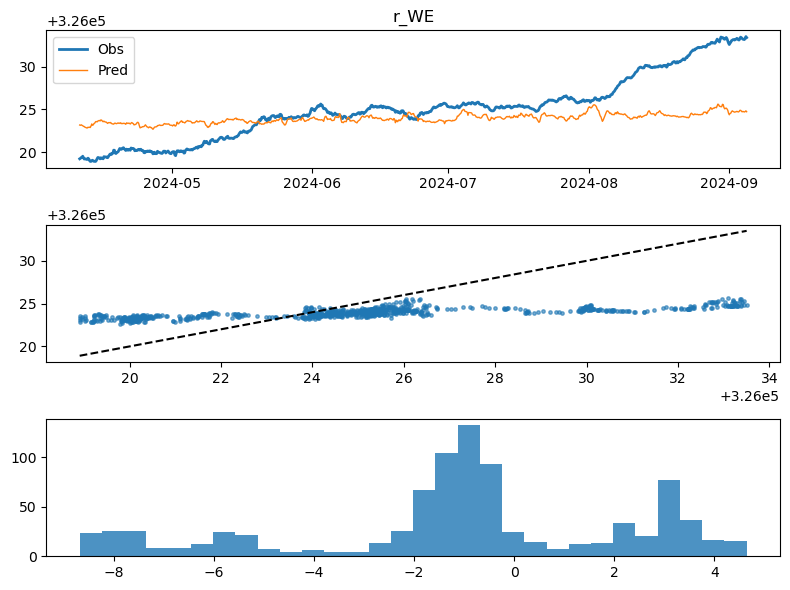

r_EW: R²= 0.036, RMSE= 3.6088 m


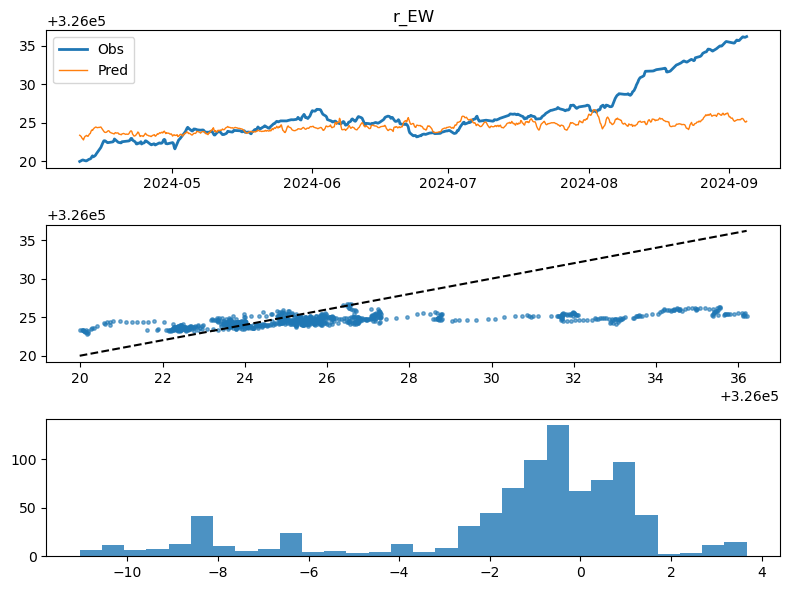

r_WC: R²= 0.086, RMSE= 2.4203 m


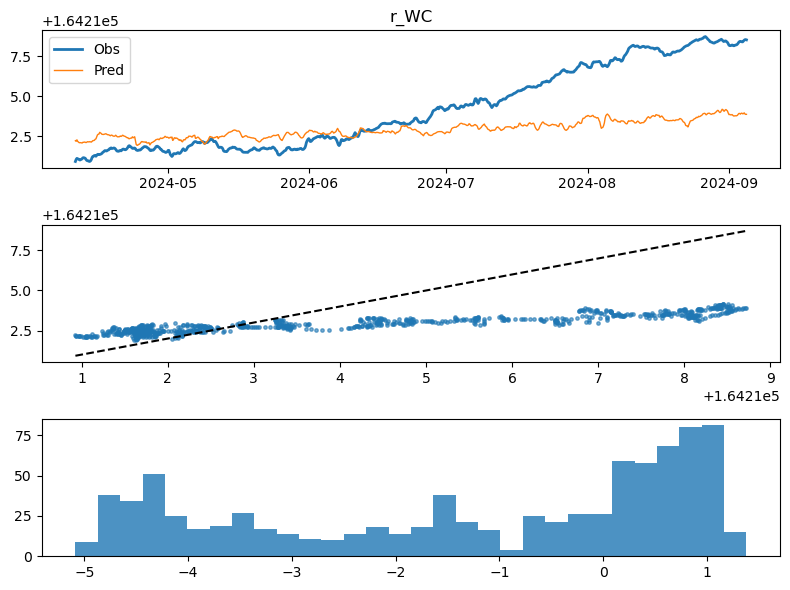

r_CW: R²= 0.161, RMSE= 2.1562 m


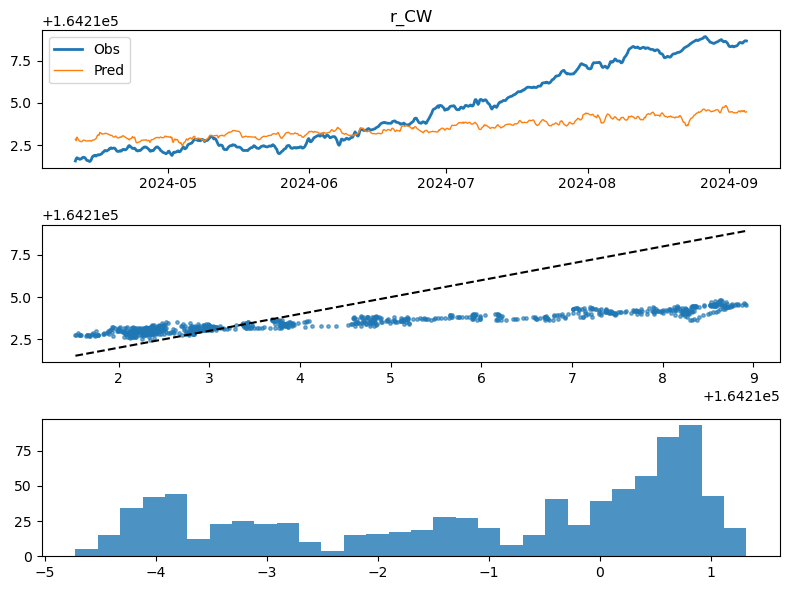

r_CE: R²= 0.107, RMSE= 1.1827 m


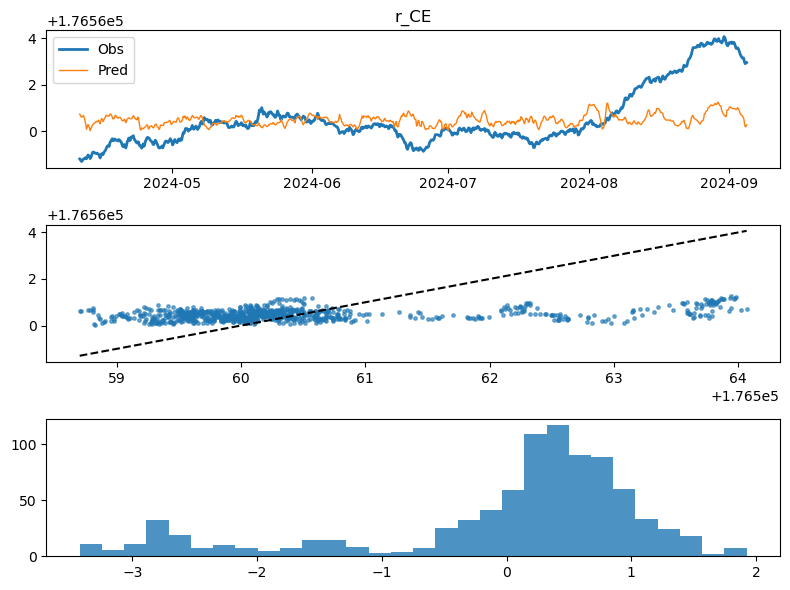

r_EC: R²= 0.008, RMSE= 1.2812 m


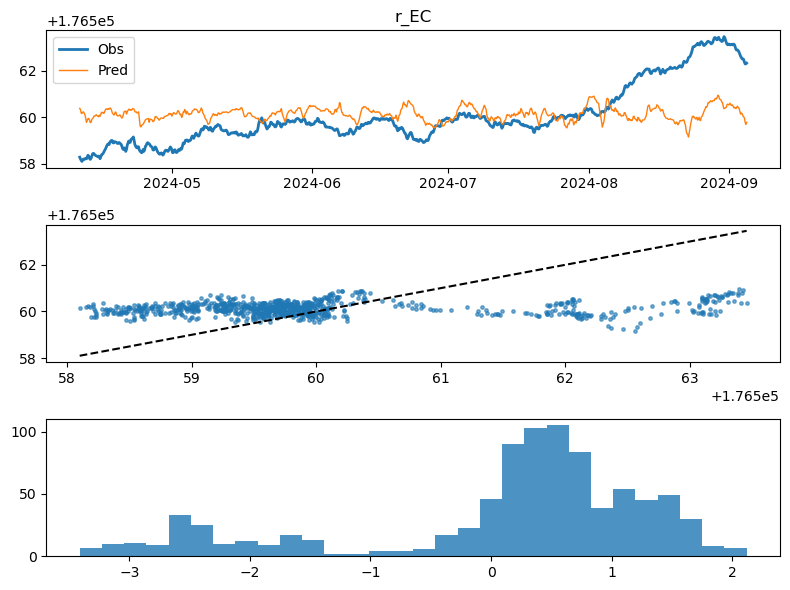

In [43]:
# -----------------------------------------------------------------------------
# 4) EVALUATE & PLOT
# -----------------------------------------------------------------------------
print("\nValidation metrics (trend+season+MLP residual):")
for i, name in enumerate(Y.columns):
    r2   = r2_score(Y_val_raw[:,i], Y_pred[:,i])
    rmse = mean_squared_error(Y_val_raw[:,i], Y_pred[:,i], squared=False)
    print(f"{name:>4}: R²={r2:6.3f}, RMSE={rmse:7.4f} m")

    fig, ax = plt.subplots(3,1,figsize=(8,6), tight_layout=True)
    ax[0].plot(t_val, Y_val_raw[:,i], label='Obs', lw=2)
    ax[0].plot(t_val, Y_pred[:,i],    label='Pred', lw=1)
    ax[0].set_title(name); ax[0].legend()
    mn,mx = Y_val_raw[:,i].min(), Y_val_raw[:,i].max()
    ax[1].scatter(Y_val_raw[:,i], Y_pred[:,i], s=6, alpha=0.6)
    ax[1].plot([mn,mx],[mn,mx],'k--')
    resid_err = Y_pred[:,i]-Y_val_raw[:,i]
    ax[2].hist(resid_err, bins=30, alpha=0.8)
    plt.show()

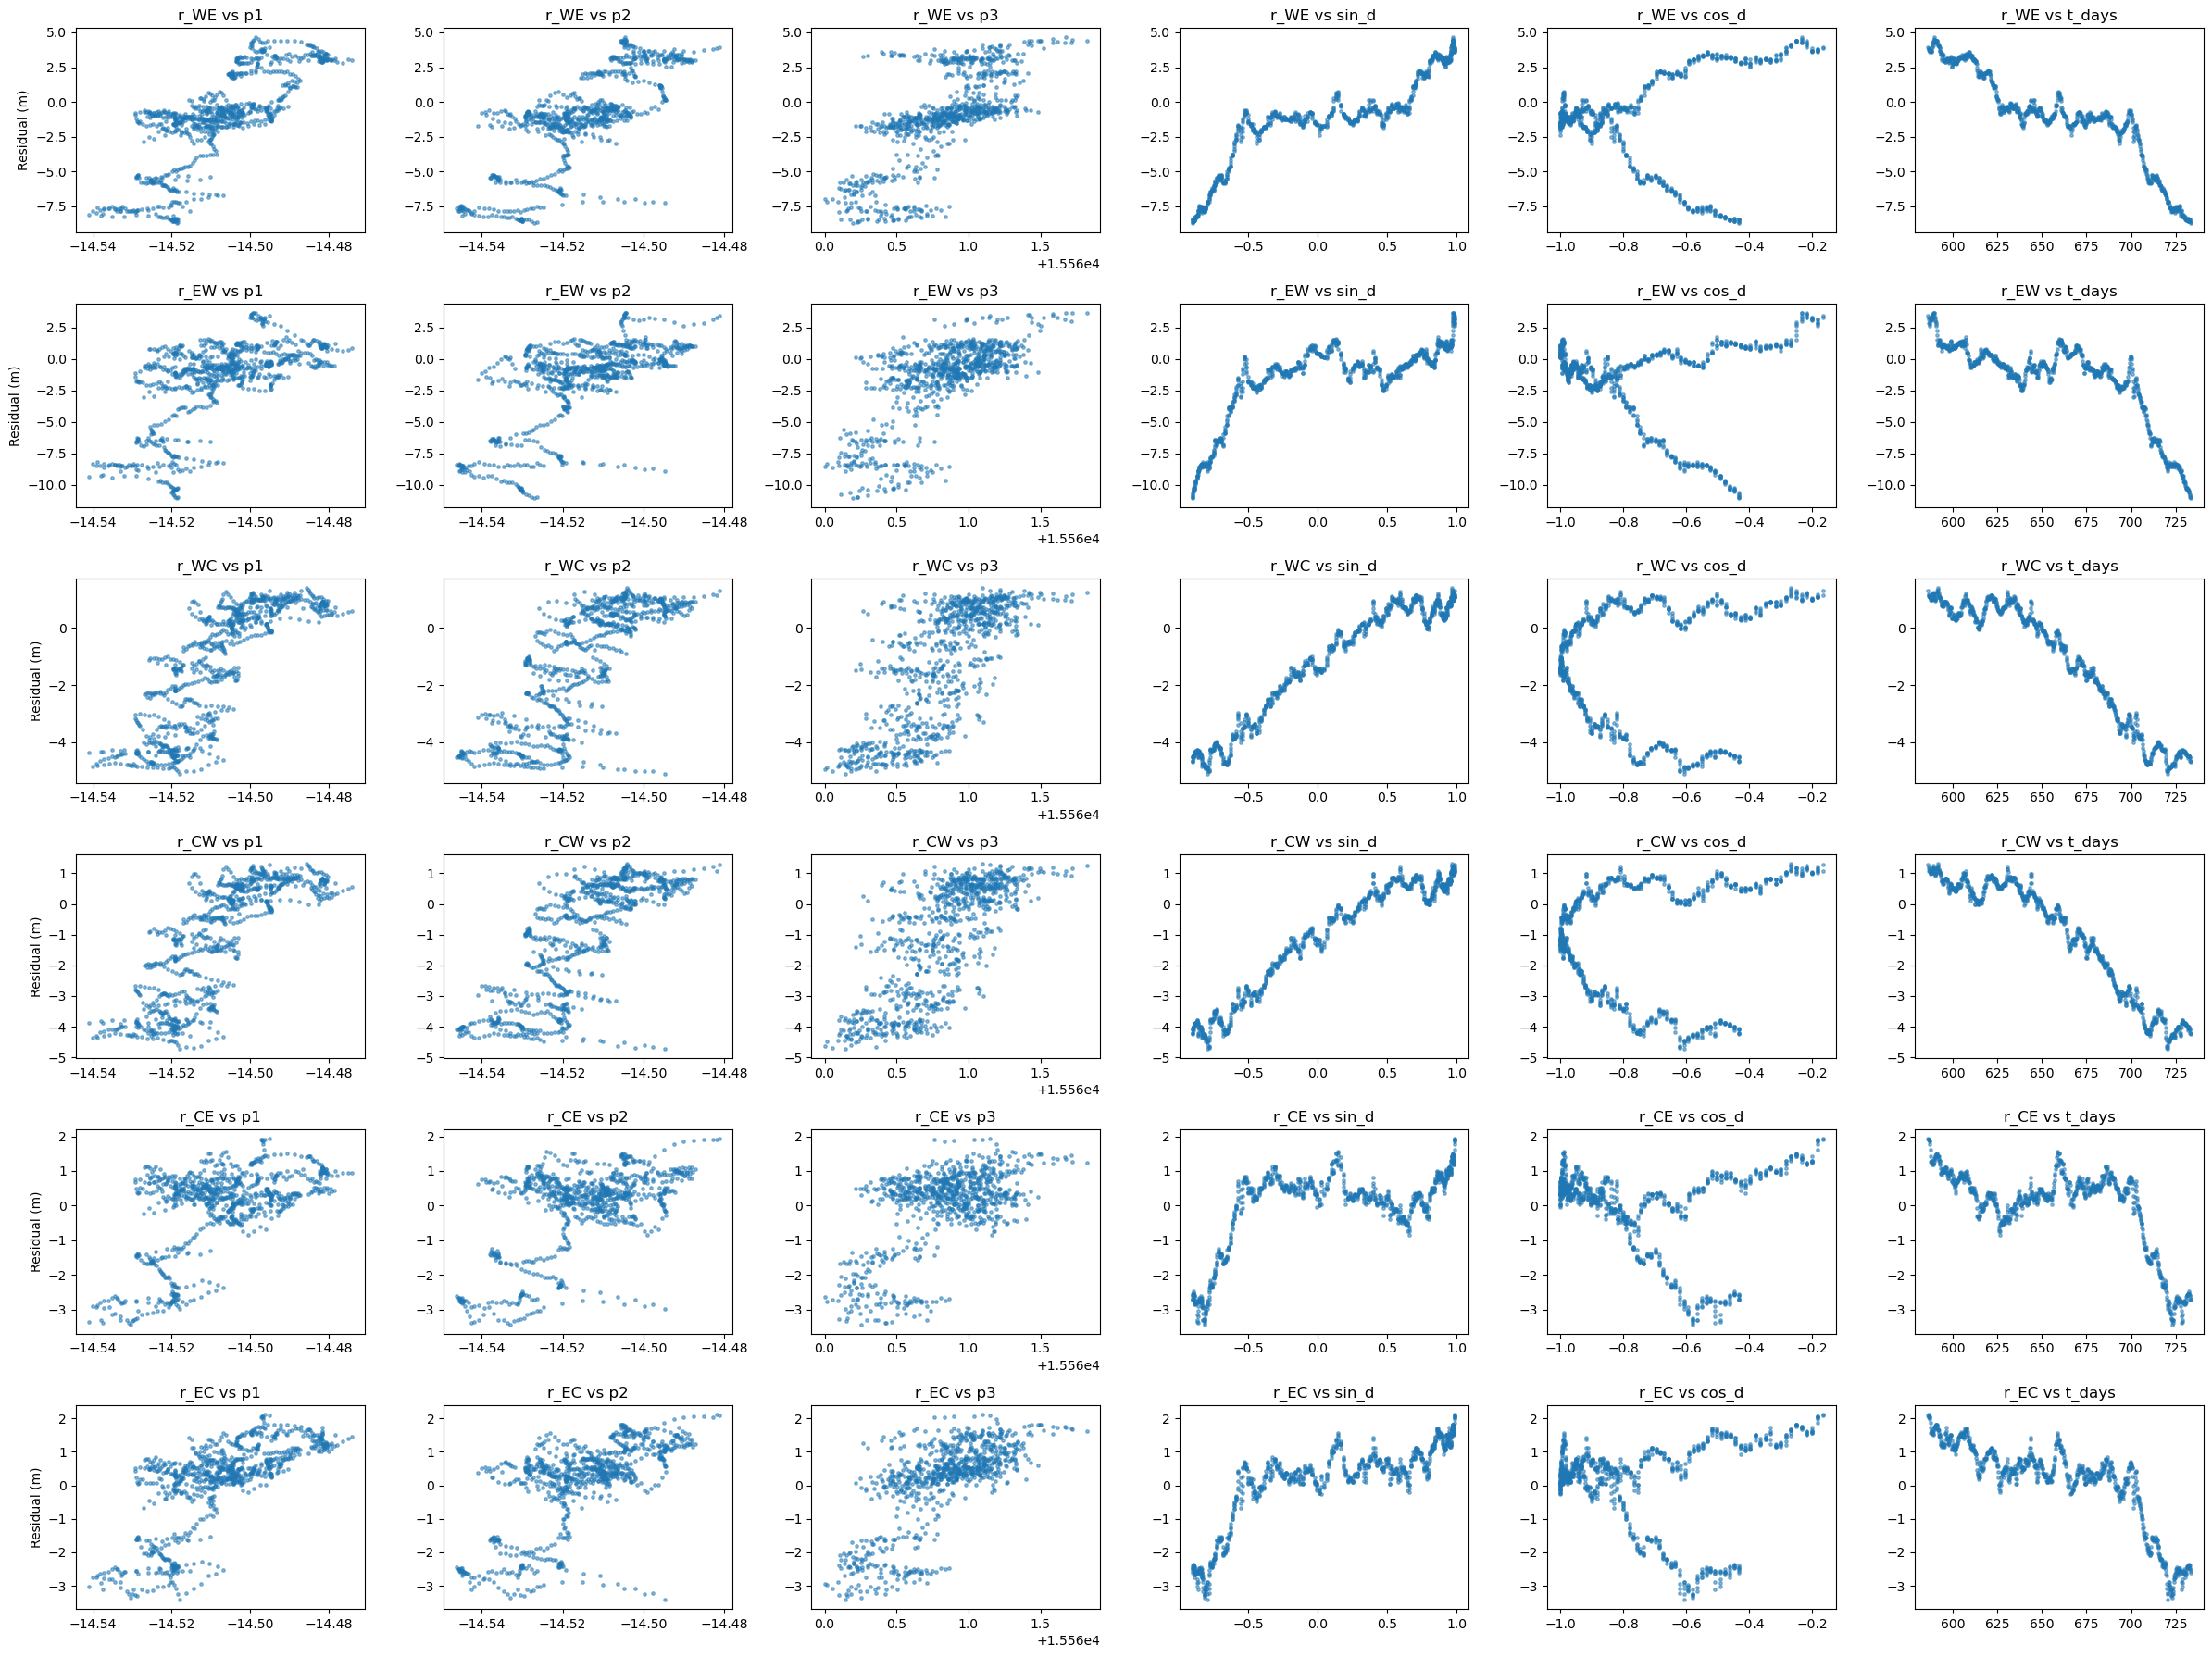


Pearson R correlations (residual vs feature):
         p1     p2     p3  sin_d  cos_d  t_days
r_WE  0.774  0.751  0.703  0.909  0.217  -0.926
r_EW  0.612  0.620  0.687  0.791 -0.072  -0.805
r_WC  0.808  0.755  0.733  0.967  0.144  -0.950
r_CW  0.793  0.752  0.741  0.965  0.138  -0.950
r_CE  0.548  0.515  0.581  0.641 -0.158  -0.664
r_EC  0.696  0.642  0.708  0.830 -0.002  -0.840


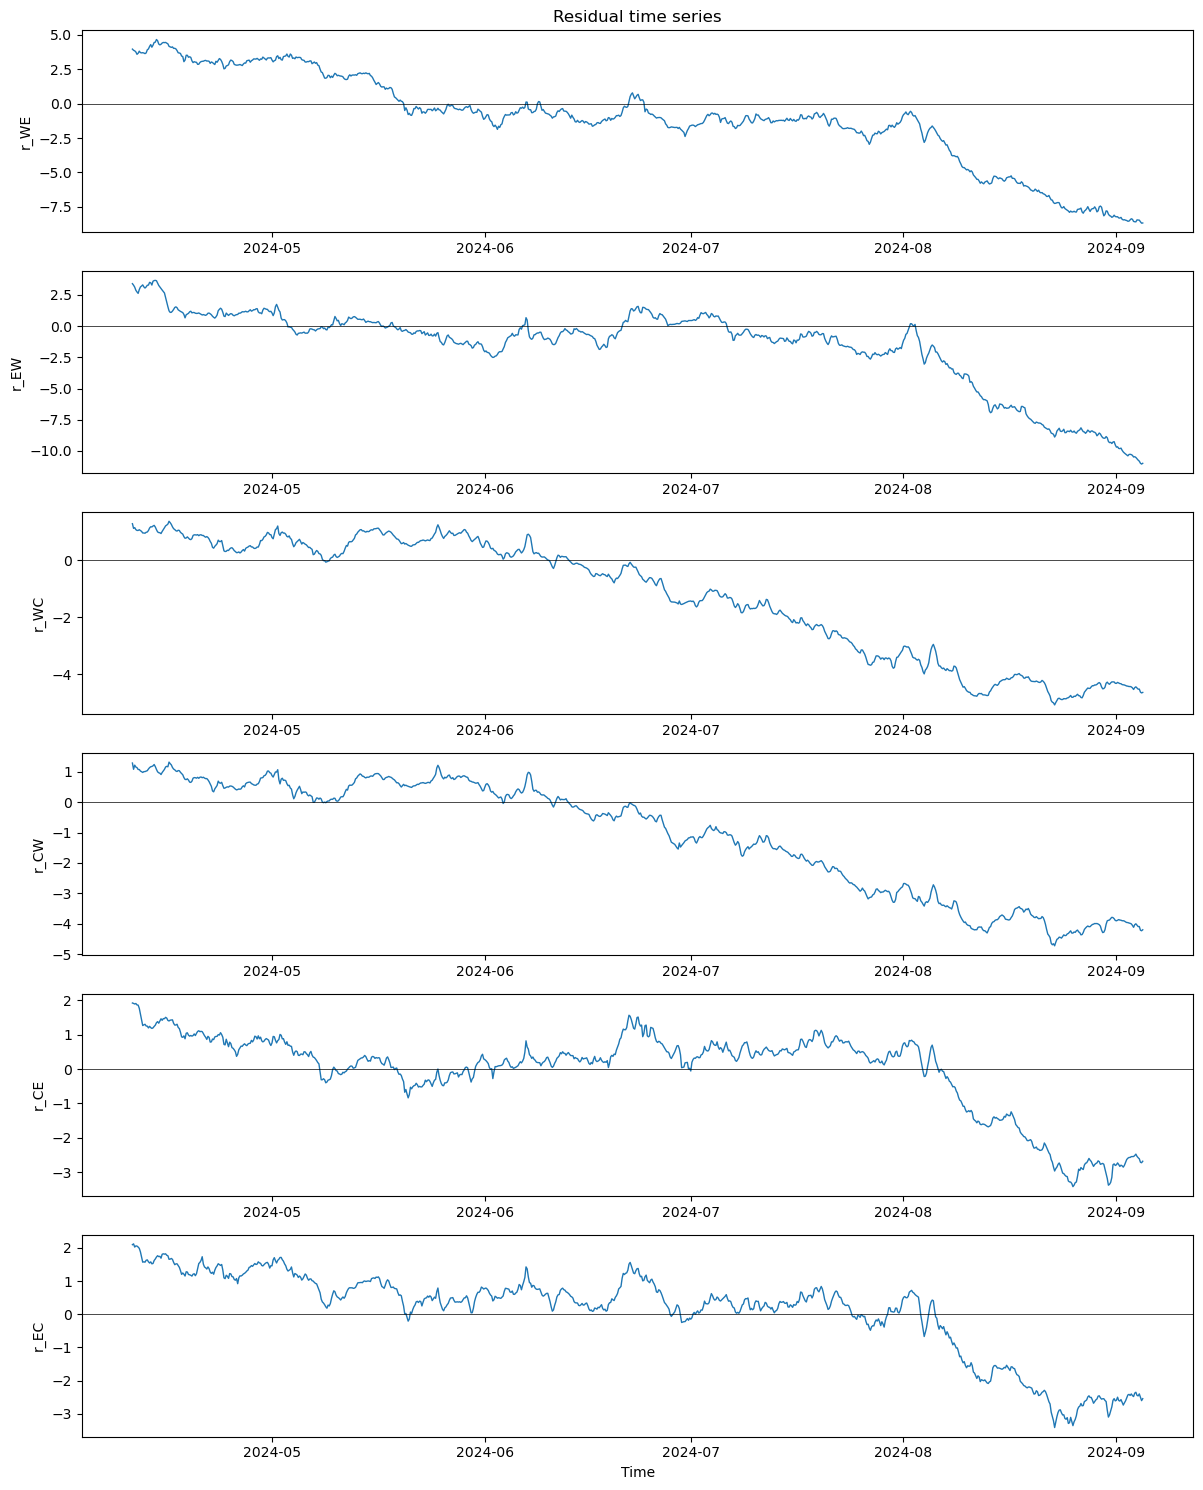

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# -----------------------------------------------------------------------------
# ASSUMES YOU HAVE:
#  - df_feat: the DataFrame used for modeling (with columns p1,p2,p3,sin_d,cos_d,t_days)
#  - Y_val_raw: shape=(N,6) absolute observed ranges
#  - Y_pred     : shape=(N,6) model predictions
#  - t_val      : shape=(N,) datetime64 index for the validation set
# -----------------------------------------------------------------------------

# 1) Residuals
resid = Y_pred - Y_val_raw  # shape (N,6)
names = ['r_WE','r_EW','r_WC','r_CW','r_CE','r_EC']

# 2) Plot residual vs each input feature
features = ['p1','p2','p3','sin_d','cos_d','t_days']
fig, axes = plt.subplots(len(names), len(features), figsize=(4*len(features), 3*len(names)), tight_layout=True)

for i, name in enumerate(names):
    for j, feat in enumerate(features):
        x = df_feat[feat].values[split:]   # validation portion
        y = resid[:, i]
        axes[i,j].scatter(x, y, s=6, alpha=0.5)
        axes[i,j].set_title(f"{name} vs {feat}")
        if j==0: axes[i,j].set_ylabel("Residual (m)")

plt.show()

# 3) Compute Pearson correlation of residuals with each feature
corrs = pd.DataFrame(index=names, columns=features)
for i, name in enumerate(names):
    for feat in features:
        x = df_feat[feat].values[split:]
        y = resid[:, i]
        mask = np.isfinite(x) & np.isfinite(y)
        corrs.loc[name, feat] = pearsonr(x[mask], y[mask])[0]

print("\nPearson R correlations (residual vs feature):")
print(corrs.astype(float).round(3))

# 4) Plot residual time series to see unexplained structure
fig, axes = plt.subplots(len(names), 1, figsize=(12, 2.5*len(names)), tight_layout=True)
for i, name in enumerate(names):
    axes[i].plot(t_val, resid[:,i], lw=1)
    axes[i].axhline(0, color='k', lw=0.5)
    axes[i].set_ylabel(name)
    if i==0: axes[i].set_title("Residual time series")
axes[-1].set_xlabel("Time")
plt.show()


In [49]:
# =============================================================================
# FULL PIPELINE: TREND + SEASON + RESIDUAL STL + INTERACTIONS + MLP
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, pathlib

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.neural_network import MLPRegressor

from statsmodels.tsa.seasonal import STL

# 0) LOAD & CLEAN
df = pd.DataFrame({
    'time': df_var['Record Time'].values,
    'p1':   df_var['p1'].values,
    'p2':   df_var['p2'].values,
    'p3':   df_var['p3'].values,
    'r_WE': df_var['d1'].values,
    'r_EW': df_var['d2'].values,
    'r_WC': df_var['d3'].values,
    'r_CW': df_var['d4'].values,
    'r_CE': df_var['d5'].values,
    'r_EC': df_var['d6'].values,
})
Y_cols = ['r_WE','r_EW','r_WC','r_CW','r_CE','r_EC']
df = df.dropna(subset=['p1','p2','p3'] + Y_cols).reset_index(drop=True)

# 1) TREND + STL DECOMPOSITION
t0 = df['time'].min()
df['t_days'] = (df['time'] - t0).dt.total_seconds() / 86400.0

trend = pd.DataFrame(index=df.index, columns=Y_cols, dtype=float)
season= pd.DataFrame(index=df.index, columns=Y_cols, dtype=float)
resid = pd.DataFrame(index=df.index, columns=Y_cols, dtype=float)

for name in Y_cols:
    # linear trend
    p = np.polyfit(df['t_days'], df[name], 1)
    trend[name] = np.polyval(p, df['t_days'])
    # STL on detrended
    detr = df[name] - trend[name]
    stl  = STL(detr, period=int(365/12), robust=True).fit()
    season[name] = stl.seasonal
    resid[name]   = stl.resid

# 2) BUILD FEATURES (incl. interactions)
df_feat = df.copy()
# attach residuals
for name in Y_cols:
    df_feat[f"{name}_resid"] = resid[name]
# seasonal phase
df_feat['doy']   = df_feat['time'].dt.dayofyear
df_feat['sin_d'] = np.sin(2*np.pi * df_feat['doy'] / 365.25)
df_feat['cos_d'] = np.cos(2*np.pi * df_feat['doy'] / 365.25)
# lagged pressures
for lag in (1,2,3):
    for p in ['p1','p2','p3']:
        df_feat[f"{p}_l{lag}"] = df_feat[p].shift(lag)
# interactions
for p in ['p1','p2','p3']:
    df_feat[f"{p}_sin"] = df_feat[p] * df_feat['sin_d']
    df_feat[f"{p}_cos"] = df_feat[p] * df_feat['cos_d']
df_feat['p1p2'] = df_feat['p1'] * df_feat['p2']
df_feat['p1p3'] = df_feat['p1'] * df_feat['p3']
df_feat['p2p3'] = df_feat['p2'] * df_feat['p3']

df_feat = df_feat.dropna().reset_index(drop=True)

# 3) ASSEMBLE X, R, and align trend/season/Y_raw
feature_cols = (
    ['p1','p2','p3'] +
    [f"{p}_l{lag}" for p in ['p1','p2','p3'] for lag in (1,2,3)] +
    ['sin_d','cos_d'] +
    [f"{p}_sin" for p in ['p1','p2','p3']] +
    [f"{p}_cos" for p in ['p1','p2','p3']] +
    ['p1p2','p1p3','p2p3']
)
X = df_feat[feature_cols].values.astype('float32')
R = df_feat[[f"{n}_resid" for n in Y_cols]].values.astype('float32')

idx = df_feat.index
trend_v  = trend.loc[idx].values
season_v = season.loc[idx].values
Y_raw_v  = df.loc[idx, Y_cols].values
t_val    = df_feat['time'].values[idx.max() - (len(idx)-len(X)):]

# 4) SPLIT
split = int(0.8 * len(df_feat))
X_train, X_val = X[:split], X[split:]
R_train, R_val = R[:split], R[split:]
trend_tr, trend_val  = trend_v[:split], trend_v[split:]
season_tr, season_val= season_v[:split], season_v[split:]
Yval_raw = Y_raw_v[split:]

# 5) SCALE & TRAIN ON RESIDUAL
xsc = StandardScaler().fit(X_train)
Xtr, Xvl = xsc.transform(X_train), xsc.transform(X_val)

ysc = StandardScaler().fit(R_train)
Rtr, Rvl = ysc.transform(R_train), ysc.transform(R_val)

mlp = MLPRegressor((64,32), max_iter=500, random_state=0)
mlp.fit(Xtr, Rtr)

# 6) PREDICT & RECONSTRUCT
R_pred = ysc.inverse_transform(mlp.predict(Xvl))
Y_pred = trend_val + season_val + R_pred

# 7) EVALUATE
print("\nHybrid trend+season+residual MLP:")
for i, name in enumerate(Y_cols):
    r2   = r2_score(Yval_raw[:,i], Y_pred[:,i])
    rmse = mean_squared_error(Yval_raw[:,i], Y_pred[:,i], squared=False)
    print(f"{name:>4}: R²={r2:6.3f}, RMSE={rmse:7.4f} m")




Hybrid trend+season+residual MLP:
r_WE: R²= 0.125, RMSE= 3.4750 m
r_EW: R²= 0.256, RMSE= 3.1714 m
r_WC: R²=-0.174, RMSE= 2.7436 m
r_CW: R²= 0.015, RMSE= 2.3355 m
r_CE: R²=-0.107, RMSE= 1.3167 m
r_EC: R²=-0.062, RMSE= 1.3256 m


In [59]:
# =============================================================================
# FULL PINN RESIDUAL MODEL SCRIPT WITH REWEIGHTED LOSS & VISUALIZATION
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, pathlib

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, backend as K
from statsmodels.tsa.seasonal import STL

# 0) LOAD & CLEAN DATA (expects df_var in memory)
df = pd.DataFrame({
    'time': df_var['Record Time'].values,
    'p1':   df_var['p1'].values,
    'p2':   df_var['p2'].values,
    'p3':   df_var['p3'].values,
    'r_WE': df_var['d1'].values,
    'r_EW': df_var['d2'].values,
    'r_WC': df_var['d3'].values,
    'r_CW': df_var['d4'].values,
    'r_CE': df_var['d5'].values,
    'r_EC': df_var['d6'].values,
})
Y_cols = ['r_WE','r_EW','r_WC','r_CW','r_CE','r_EC']
df.dropna(subset=['p1','p2','p3'] + Y_cols, inplace=True)
df.reset_index(drop=True, inplace=True)

# 1) DECOMPOSE TREND & SEASON
# compute time in days
t0 = df['time'].min()
df['t_days'] = (df['time'] - t0).dt.total_seconds() / 86400.0
trend = pd.DataFrame(index=df.index, columns=Y_cols, dtype=float)
season = pd.DataFrame(index=df.index, columns=Y_cols, dtype=float)
resid = pd.DataFrame(index=df.index, columns=Y_cols, dtype=float)
for name in Y_cols:
    # linear trend
    coeffs = np.polyfit(df['t_days'], df[name], 1)
    trend[name] = np.polyval(coeffs, df['t_days'])
    # STL seasonality
    detrended = df[name] - trend[name]
    stl = STL(detrended, period=int(365/12), robust=True).fit()
    season[name] = stl.seasonal
    resid[name] = stl.resid

# 2) FEATURE ENGINEERING
# build modeling frame
df_feat = df.copy()
for name in Y_cols:
    df_feat[f"{name}_resid"] = resid[name]
omega = 2 * np.pi / 365.25
for feat in ['sin1','cos1']:
    df_feat[feat] = np.sin(omega * df_feat['t_days']) if feat=='sin1' else np.cos(omega * df_feat['t_days'])
for lag in (1,2,3):
    for p in ['p1','p2','p3']:
        df_feat[f"{p}_l{lag}"] = df_feat[p].shift(lag)
df_feat.dropna(inplace=True)
df_feat.reset_index(drop=True, inplace=True)

feature_cols = ['p1','p2','p3','sin1','cos1','t_days'] + \
    [f"{p}_l{lag}" for p in ['p1','p2','p3'] for lag in (1,2,3)]
X_raw = df_feat[feature_cols].astype('float32').values
y_resid_raw = df_feat[[f"{n}_resid" for n in Y_cols]].astype('float32').values
idx = df_feat.index
y_trend = trend.loc[idx].values
Y_season = season.loc[idx].values
Y_true = df.loc[idx, Y_cols].values

total_samples = len(df_feat)
split = int(0.8 * total_samples)

# 3) SCALE & SPLIT
scaler_x = StandardScaler().fit(X_raw[:split])
X = scaler_x.transform(X_raw)
scaler_y = StandardScaler().fit(y_resid_raw[:split])
y_resid = scaler_y.transform(y_resid_raw)
X_train, X_val = X[:split], X[split:]
y_train, y_val = y_resid[:split], y_resid[split:]
trend_val = y_trend[split:]
season_val = Y_season[split:]
Y_val_true = Y_true[split:]
t_val = df_feat['time'].values[split:]

# 4) BUILD PINN MODEL
inputs = layers.Input(shape=(X.shape[1],))
x = layers.Dense(128, activation='relu')(inputs)
x = layers.Dense(64, activation='relu')(x)
y_resid_pred = layers.Dense(len(Y_cols), activation='linear')(x)
model = models.Model(inputs, y_resid_pred)

def pinn_loss(y_true, y_pred):
    # data fit
    L_mse = K.mean(K.square(y_true - y_pred))
    # symmetry
    CE, EC = y_pred[:,4], y_pred[:,5]
    CW, WC = y_pred[:,3], y_pred[:,2]
    L_sym = K.mean(K.square(CE - EC) + K.square(CW - WC))
    # closure
    EW = y_pred[:,1]
    L_clo = K.mean(K.square(CE + CW - EW))
    # smoothness
    diff2 = y_pred[2:] - 2*y_pred[1:-1] + y_pred[:-2]
    L_smo = K.mean(K.square(diff2))
    # rebalanced weights
    return (10.0 * L_mse
          + 0.1  * L_sym
          + 0.1  * L_clo
          + 0.01 * L_smo)

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss=pinn_loss)

# 5) TRAIN
early = callbacks.EarlyStopping(monitor='loss', patience=50, restore_best_weights=True)
model.fit(X_train, y_train, epochs=500, batch_size=total_samples, callbacks=[early], verbose=1)

# 6) PREDICT & RECONSTRUCT full range
resid_pred = model.predict(X_val)
Y_pred_full = trend_val + season_val + scaler_y.inverse_transform(resid_pred)

# 7) EVALUATE
def print_metrics(Y_true, Y_pred):
    for i, name in enumerate(Y_cols):
        r2 = r2_score(Y_true[:,i], Y_pred[:,i])
        rmse = mean_squared_error(Y_true[:,i], Y_pred[:,i], squared=False)
        print(f"{name}: R²={r2:.3f}, RMSE={rmse:.3f} m")

print("Validation metrics (PINN residual reweighted):")
print_metrics(Y_val_true, Y_pred_full)



Epoch 1/500
1/1 [==============================] - 1s 715ms/step - loss: 10.8176
Epoch 2/500
1/1 [==============================] - 0s 6ms/step - loss: 10.4816
Epoch 3/500
1/1 [==============================] - 0s 6ms/step - loss: 10.2550
Epoch 4/500
1/1 [==============================] - 0s 6ms/step - loss: 10.1046
Epoch 5/500
1/1 [==============================] - 0s 6ms/step - loss: 9.9988
Epoch 6/500
1/1 [==============================] - 0s 5ms/step - loss: 9.9136
Epoch 7/500
1/1 [==============================] - 0s 5ms/step - loss: 9.8361
Epoch 8/500
1/1 [==============================] - 0s 6ms/step - loss: 9.7624
Epoch 9/500
1/1 [==============================] - 0s 5ms/step - loss: 9.6932
Epoch 10/500
1/1 [==============================] - 0s 6ms/step - loss: 9.6305
Epoch 11/500
1/1 [==============================] - 0s 6ms/step - loss: 9.5760
Epoch 12/500
1/1 [==============================] - 0s 6ms/step - loss: 9.5296
Epoch 13/500
1/1 [==============================] - 0s 

1/1 [==============================] - 0s 5ms/step - loss: 7.3540
Epoch 105/500
1/1 [==============================] - 0s 6ms/step - loss: 7.3283
Epoch 106/500
1/1 [==============================] - 0s 5ms/step - loss: 7.3031
Epoch 107/500
1/1 [==============================] - 0s 5ms/step - loss: 7.2775
Epoch 108/500
1/1 [==============================] - 0s 5ms/step - loss: 7.2518
Epoch 109/500
1/1 [==============================] - 0s 5ms/step - loss: 7.2254
Epoch 110/500
1/1 [==============================] - 0s 5ms/step - loss: 7.1993
Epoch 111/500
1/1 [==============================] - 0s 5ms/step - loss: 7.1737
Epoch 112/500
1/1 [==============================] - 0s 5ms/step - loss: 7.1477
Epoch 113/500
1/1 [==============================] - 0s 5ms/step - loss: 7.1218
Epoch 114/500
1/1 [==============================] - 0s 5ms/step - loss: 7.0962
Epoch 115/500
1/1 [==============================] - 0s 5ms/step - loss: 7.0699
Epoch 116/500
1/1 [==============================] - 0

1/1 [==============================] - 0s 5ms/step - loss: 4.9766
Epoch 207/500
1/1 [==============================] - 0s 5ms/step - loss: 4.9610
Epoch 208/500
1/1 [==============================] - 0s 5ms/step - loss: 4.9453
Epoch 209/500
1/1 [==============================] - 0s 5ms/step - loss: 4.9310
Epoch 210/500
1/1 [==============================] - 0s 5ms/step - loss: 4.9167
Epoch 211/500
1/1 [==============================] - 0s 5ms/step - loss: 4.9015
Epoch 212/500
1/1 [==============================] - 0s 5ms/step - loss: 4.8878
Epoch 213/500
1/1 [==============================] - 0s 5ms/step - loss: 4.8743
Epoch 214/500
1/1 [==============================] - 0s 5ms/step - loss: 4.8619
Epoch 215/500
1/1 [==============================] - 0s 5ms/step - loss: 4.8490
Epoch 216/500
1/1 [==============================] - 0s 5ms/step - loss: 4.8323
Epoch 217/500
1/1 [==============================] - 0s 5ms/step - loss: 4.8156
Epoch 218/500
1/1 [==============================] - 0

1/1 [==============================] - 0s 5ms/step - loss: 3.9850
Epoch 309/500
1/1 [==============================] - 0s 5ms/step - loss: 3.9743
Epoch 310/500
1/1 [==============================] - 0s 5ms/step - loss: 3.9767
Epoch 311/500
1/1 [==============================] - 0s 5ms/step - loss: 3.9700
Epoch 312/500
1/1 [==============================] - 0s 6ms/step - loss: 3.9571
Epoch 313/500
1/1 [==============================] - 0s 5ms/step - loss: 3.9547
Epoch 314/500
1/1 [==============================] - 0s 5ms/step - loss: 3.9519
Epoch 315/500
1/1 [==============================] - 0s 6ms/step - loss: 3.9424
Epoch 316/500
1/1 [==============================] - 0s 5ms/step - loss: 3.9359
Epoch 317/500
1/1 [==============================] - 0s 5ms/step - loss: 3.9310
Epoch 318/500
1/1 [==============================] - 0s 5ms/step - loss: 3.9269
Epoch 319/500
1/1 [==============================] - 0s 5ms/step - loss: 3.9196
Epoch 320/500
1/1 [==============================] - 0

1/1 [==============================] - 0s 5ms/step - loss: 3.4761
Epoch 411/500
1/1 [==============================] - 0s 5ms/step - loss: 3.4734
Epoch 412/500
1/1 [==============================] - 0s 5ms/step - loss: 3.4697
Epoch 413/500
1/1 [==============================] - 0s 5ms/step - loss: 3.4652
Epoch 414/500
1/1 [==============================] - 0s 5ms/step - loss: 3.4612
Epoch 415/500
1/1 [==============================] - 0s 5ms/step - loss: 3.4564
Epoch 416/500
1/1 [==============================] - 0s 5ms/step - loss: 3.4518
Epoch 417/500
1/1 [==============================] - 0s 5ms/step - loss: 3.4479
Epoch 418/500
1/1 [==============================] - 0s 5ms/step - loss: 3.4425
Epoch 419/500
1/1 [==============================] - 0s 5ms/step - loss: 3.4391
Epoch 420/500
1/1 [==============================] - 0s 5ms/step - loss: 3.4348
Epoch 421/500
1/1 [==============================] - 0s 5ms/step - loss: 3.4319
Epoch 422/500
1/1 [==============================] - 0

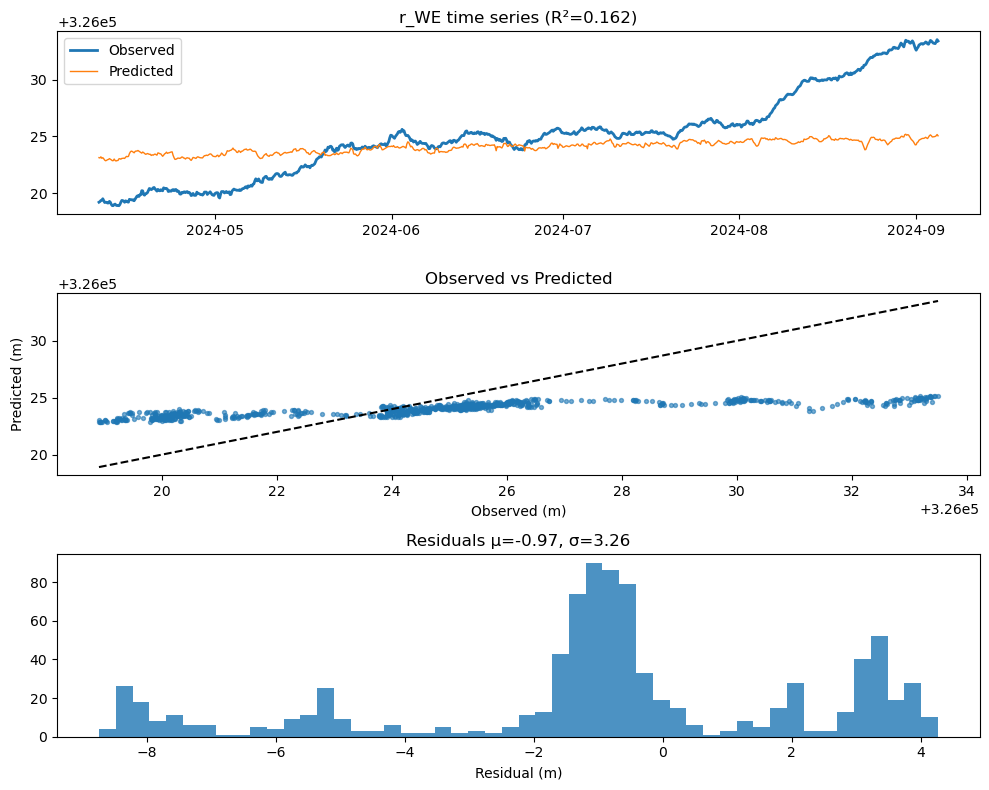

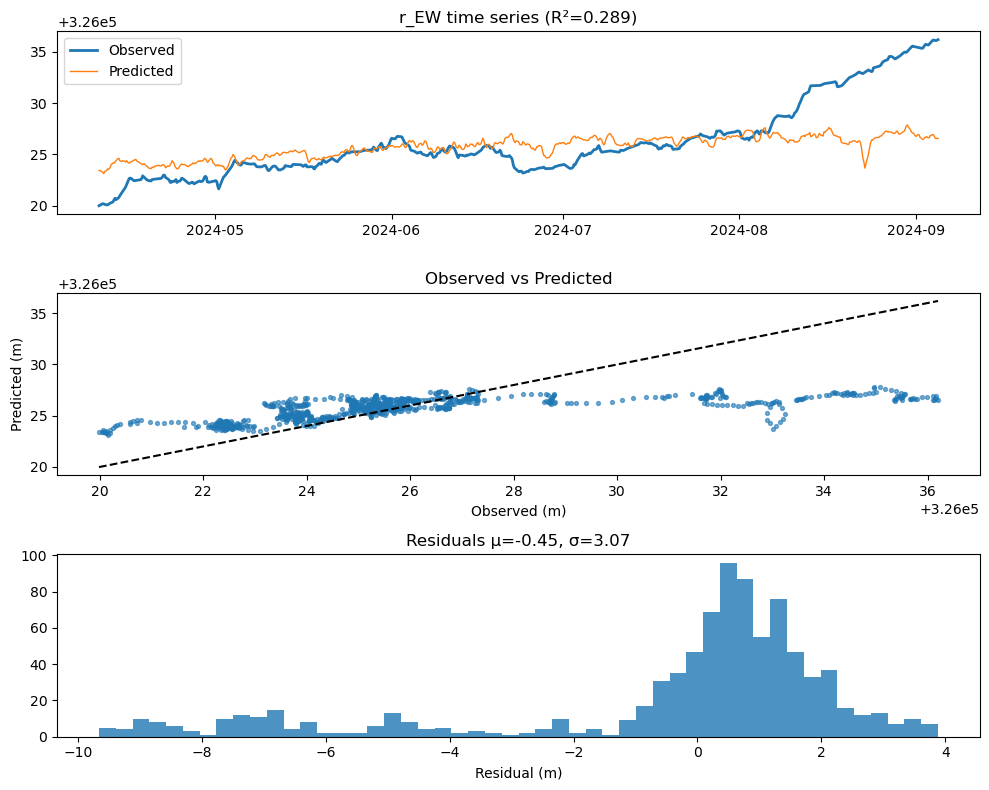

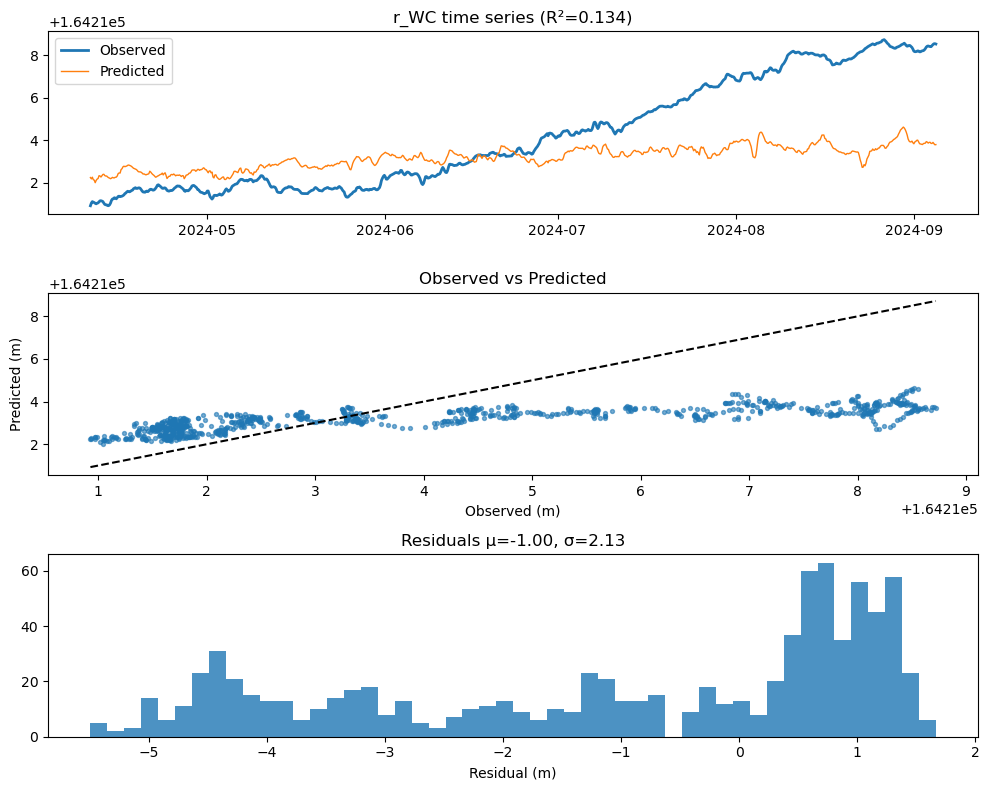

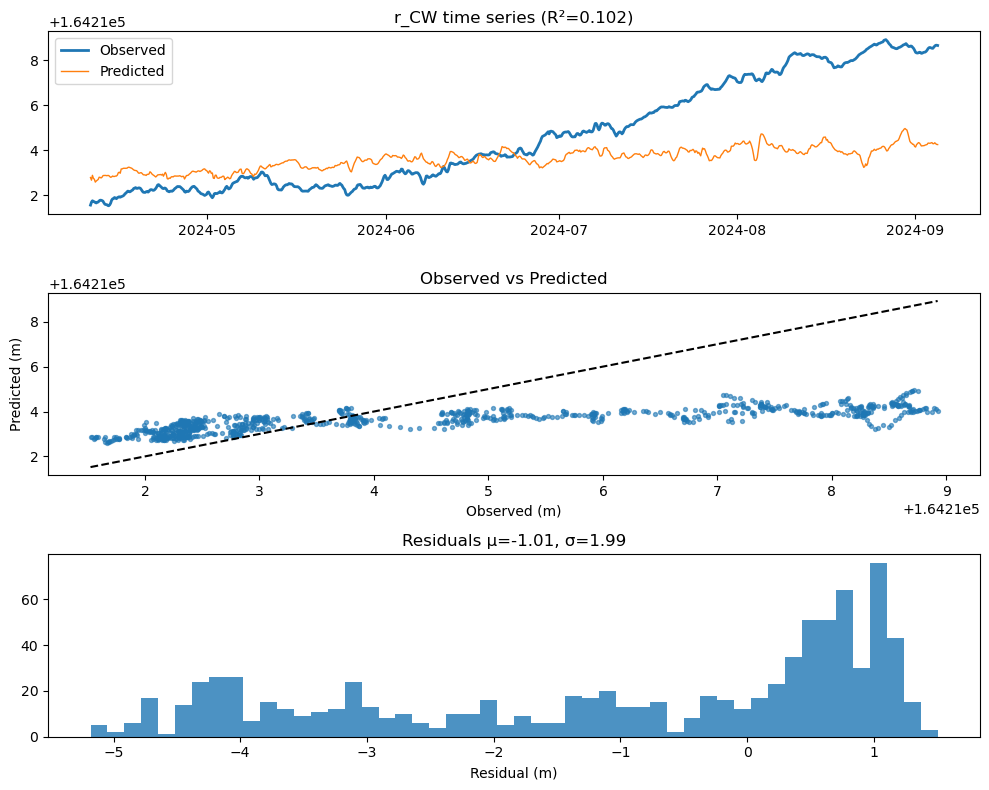

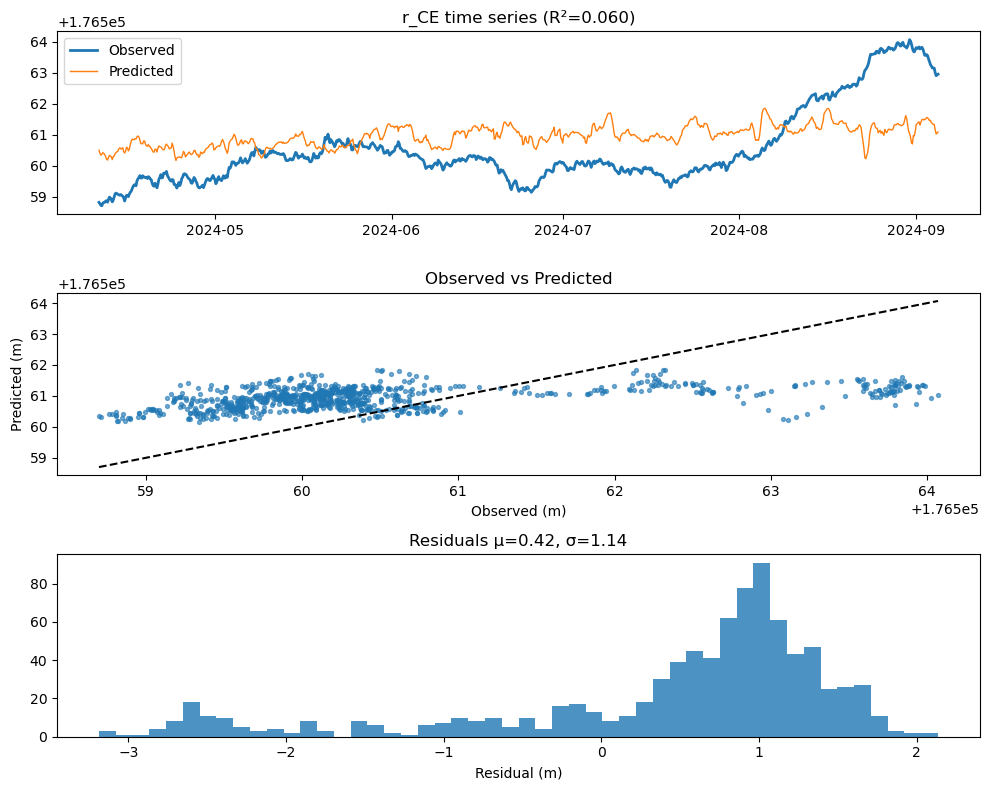

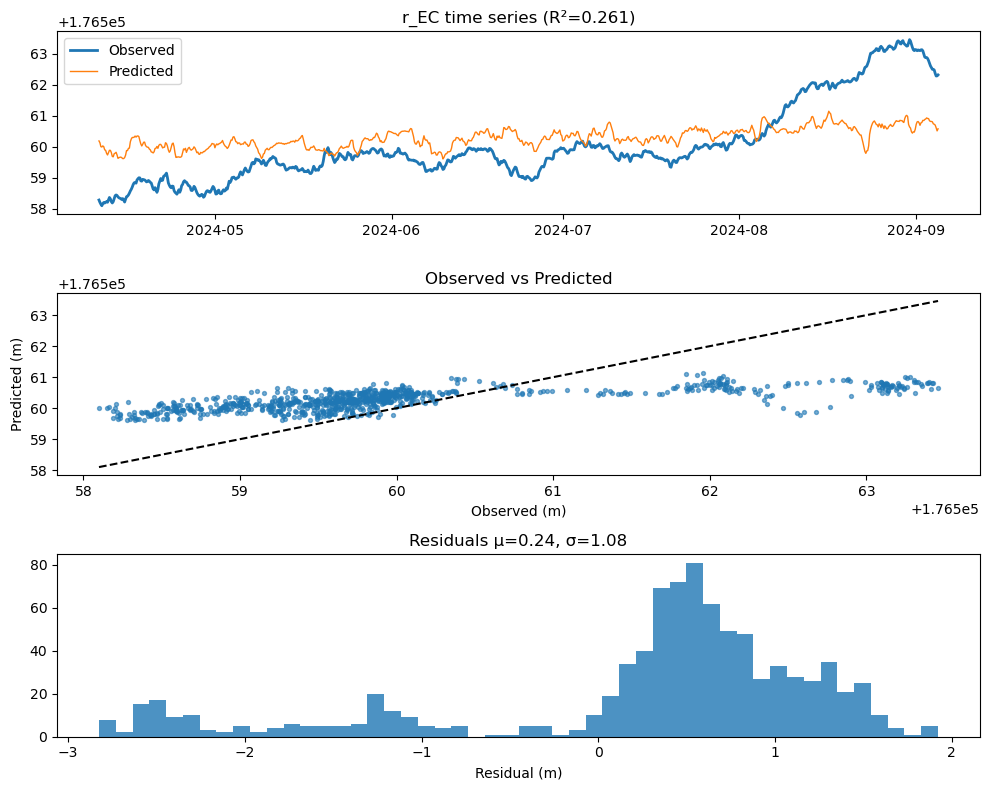

In [60]:
# 8) VISUALIZATION
for i, name in enumerate(Y_cols):
    fig, axes = plt.subplots(3,1, figsize=(10,8), tight_layout=True)
    # time-series overlay
    axes[0].plot(t_val, Y_val_true[:,i], label='Observed', lw=2)
    axes[0].plot(t_val, Y_pred_full[:,i], label='Predicted', lw=1)
    axes[0].set_title(f"{name} time series (R²={r2_score(Y_val_true[:,i], Y_pred_full[:,i]):.3f})")
    axes[0].legend()
    # scatter
    axes[1].scatter(Y_val_true[:,i], Y_pred_full[:,i], s=8, alpha=0.6)
    mn, mx = Y_val_true[:,i].min(), Y_val_true[:,i].max()
    axes[1].plot([mn,mx],[mn,mx],'k--')
    axes[1].set_xlabel('Observed (m)')
    axes[1].set_ylabel('Predicted (m)')
    axes[1].set_title('Observed vs Predicted')
    # residual histogram
    resid_err = Y_pred_full[:,i] - Y_val_true[:,i]
    axes[2].hist(resid_err, bins=50, alpha=0.8)
    axes[2].set_xlabel('Residual (m)')
    axes[2].set_title(f'Residuals μ={resid_err.mean():.2f}, σ={resid_err.std():.2f}')
    plt.show()

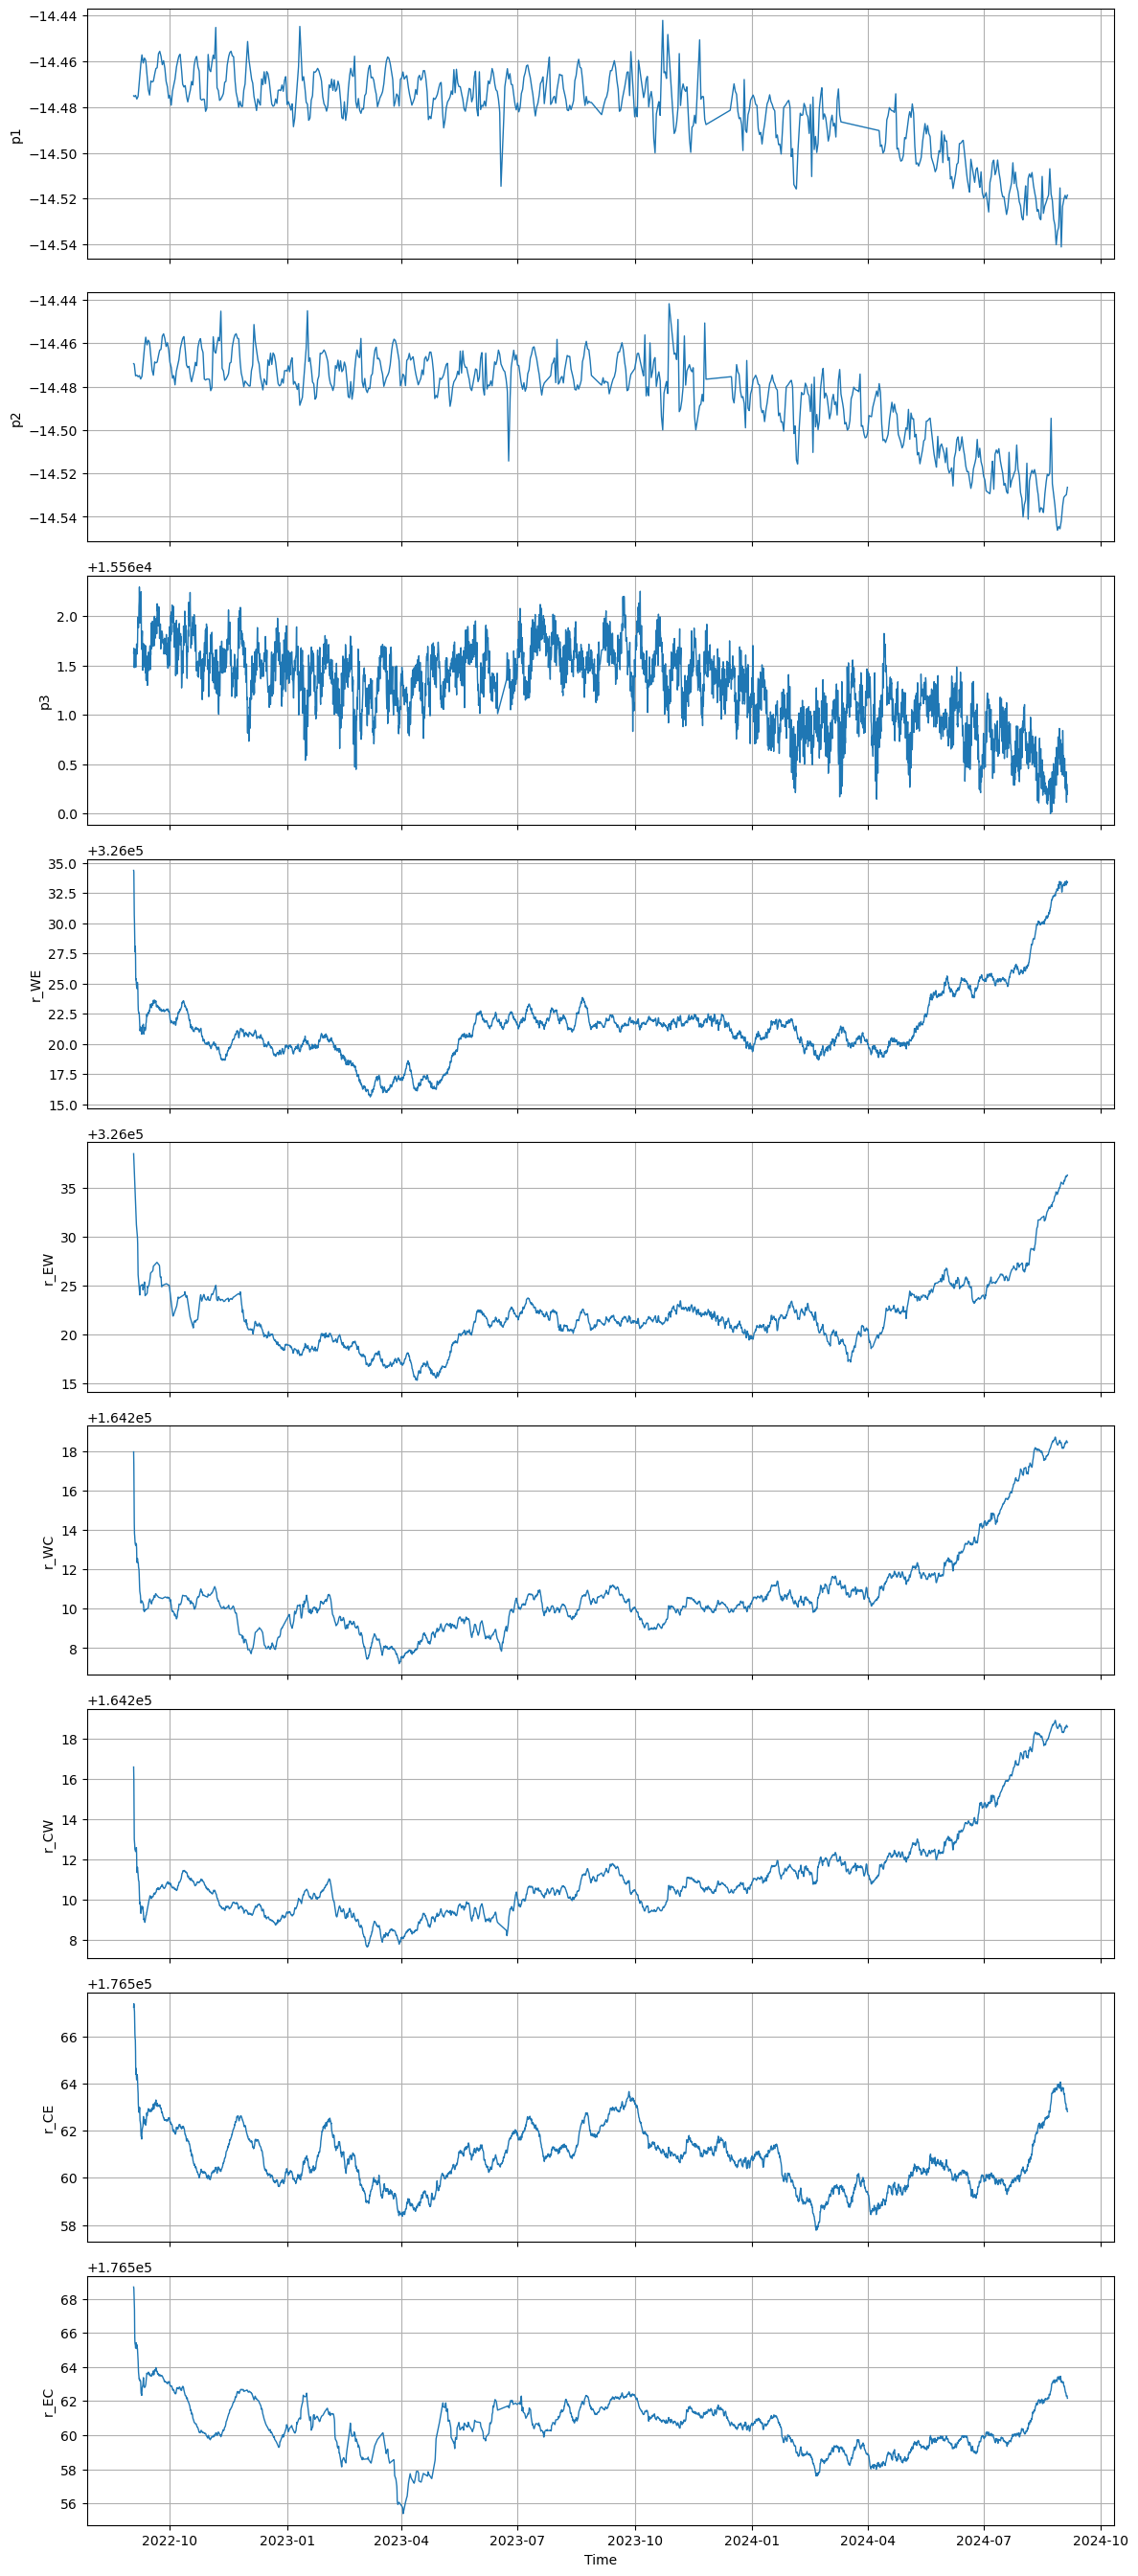

In [61]:
import matplotlib.pyplot as plt

# Recreate df if needed, then:
variables = ['p1', 'p2', 'p3', 'r_WE', 'r_EW', 'r_WC', 'r_CW', 'r_CE', 'r_EC']
fig, axes = plt.subplots(len(variables), 1, figsize=(12, 3*len(variables)), sharex=True, tight_layout=True)

for ax, var in zip(axes, variables):
    ax.plot(df['time'], df[var], lw=1)
    ax.set_ylabel(var)
    ax.grid(True)

axes[-1].set_xlabel('Time')
plt.show()
